In [1]:
#Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import math
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, Dataset, random_split, RandomSampler
from torch.utils.data.sampler import SubsetRandomSampler
from tqdm import tqdm
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import requests
import random
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import re
import nltk
import matplotlib.ticker as ticker # Import ticker for showAttention

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

In [4]:
text = "Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text. At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model. One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks. Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time. Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants. In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology."

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.encoding = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        self.encoding[:, 0::2] = torch.sin(position * div_term)
        self.encoding[:, 1::2] = torch.cos(position * div_term)
        self.encoding = self.encoding.unsqueeze(0).to(device)

    def forward(self, x):
        return x + self.encoding[:, :x.size(1)].detach()

class CharTransformer(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, nhead):
        super(CharTransformer, self).__init__()
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size)
        encoder_layers = nn.TransformerEncoderLayer(hidden_size, nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.pos_encoder(embedded)
        transformer_output = self.transformer_encoder(embedded)
        output = self.fc(transformer_output)
        return output


In [6]:
class CharCrossAttention(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers, nhead):
        super(CharCrossAttention, self).__init__()

        # Embeddings & Positional Encoding
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size)

        # Full Transformer aka Cross Attention
        self.transformer = nn.Transformer(
            d_model=hidden_size,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            batch_first=True
        )

        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def generate_square_subsequent_mask(self, sz):
        """
        Prevents the decoder from "looking ahead" at future characters
        during the cross-attention and self-attention phases.
        """
        mask = (torch.triu(torch.ones(sz, sz, device=device)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, src, tgt):
        # Apply embeddings and positional encodings
        src_emb = self.pos_encoder(self.embedding(src))
        tgt_emb = self.pos_encoder(self.embedding(tgt))

        tgt_mask = self.generate_square_subsequent_mask(tgt.size(1))

        transformer_out = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=tgt_mask
        )

        return self.fc_out(transformer_out)

In [7]:
def count_parameters(model):
    print(sum(p.numel() for p in model.parameters() if p.requires_grad))

# Prediction function for encoder-only models (e.g., CharTransformer)
def predict_next_char_encoder_only(model, char_to_ix, ix_to_char, initial_str, seq_length):
    model.eval()
    with torch.no_grad():
        initial_input = torch.tensor([char_to_ix[c] for c in initial_str[-seq_length:]], dtype=torch.long).unsqueeze(0).to(device)
        prediction = model(initial_input)
        # The model outputs a prediction for each token in the sequence.
        # We are interested in the prediction for the *next* character,
        # which corresponds to the output associated with the last input token.
        predicted_logits_for_next_char = prediction[:, -1, :] # Select logits for the last token
        predicted_index = torch.argmax(predicted_logits_for_next_char, dim=-1).item()
        return ix_to_char[predicted_index]

# Prediction function for sequence-to-sequence models (e.g., CharCrossAttention, Seq2SeqTransformer)
def predict_next_char_seq2seq(model, char_to_ix, ix_to_char, initial_str, seq_length, device):
    model.eval()
    with torch.no_grad():
        # Encode the initial string as source input for the encoder
        src_input = torch.tensor([char_to_ix[c] for c in initial_str[-seq_length:]], dtype=torch.long).unsqueeze(0).to(device)

        # For predicting the 'next' character immediately after the `initial_str`,
        # we use the `src_input` itself as the `tgt` input for a single prediction step.
        # This leverages how the model was trained (batch_x as src, batch_y as tgt where batch_y is shifted batch_x).
        # In an auto-regressive generation scenario, you'd typically feed the last predicted character
        # as the next target input, but for this specific 'predict_next_char' utility, feeding the
        # sequence as both src and tgt (where the model will mask future tokens in tgt) is appropriate
        # to get the next character prediction for the *end* of the sequence.
        tgt_input = src_input # Simulates feeding the input sequence to the decoder to predict the next token

        output = model(src_input, tgt_input)
        # The output is (batch_size, tgt_seq_len, vocab_size). We want the prediction
        # for the character *after* the last one in the input, which corresponds to
        # the last position of the target sequence's output.
        predicted_logits_for_next_char = output[:, -1, :]
        predicted_index = torch.argmax(predicted_logits_for_next_char, dim=-1).item()
        return ix_to_char[predicted_index]

def plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies, title="Model"):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Losses on left Y-axis
    ax1.plot(train_losses, label='Train Loss', color='blue')
    ax1.plot(val_losses, label='Val Loss', color='orange')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend(loc='upper left')

    # Plot Accuracies on right Y-axis
    ax2 = ax1.twinx()
    ax2.plot(train_accuracies, label='Train Accuracy', color='purple', linestyle='dashed') # NEW: Plotting Train Acc
    ax2.plot(val_accuracies, label='Val Accuracy', color='green', linestyle='dashed')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend(loc='upper right')

    plt.title(f'{title} - Training Metrics')
    plt.grid(True)
    plt.show()

In [8]:
chars = sorted(list(set(text)))
ix_to_char = {i: ch for i, ch in enumerate(chars)}
char_to_ix = {ch: i for i, ch in enumerate(chars)}
chars = sorted(list(set(text)))

def prepare_data(seq_length):
    X, y = [], []
    for i in range(len(text) - seq_length - 1):
        X.append([char_to_ix[ch] for ch in text[i:i + seq_length]])
        y.append([char_to_ix[ch] for ch in text[i+1:i + seq_length + 1]])

    X_train, X_val, y_train, y_val = train_test_split(np.array(X), np.array(y), test_size=0.2, random_state=42)

    # Convert to tensors & loaders
    train_data = TensorDataset(torch.tensor(X_train, dtype=torch.long), torch.tensor(y_train, dtype=torch.long))
    val_data = TensorDataset(torch.tensor(X_val, dtype=torch.long), torch.tensor(y_val, dtype=torch.long))
    train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=64)
    return train_loader, val_loader

def train_char_transformer(seq_length, epochs=50, learning_rate=0.001, hidden_size= 128, n_layers=2, nhead=2, patience=5):
    print(f"\n--- Training for Sequence Length: {seq_length} ---")
    train_loader, val_loader = prepare_data(seq_length)

    # Initialize model, loss, and optimizer
    model = CharTransformer(len(chars), hidden_size=hidden_size, output_size=len(chars), num_layers=n_layers, nhead=nhead).to(device)
    count_parameters(model)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    epoch_times = [] # Keep track of time per epoch

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
      start_time = time.time()
      model.train()
      total_loss = 0
      for batch_x, batch_y in train_loader:
          batch_x, batch_y = batch_x.to(device), batch_y.to(device)
          optimizer.zero_grad()
          output = model(batch_x)
          loss = criterion(output.transpose(1, 2), batch_y)
          loss.backward()
          optimizer.step()
          total_loss += loss.item()
      train_losses.append(total_loss/len(train_loader))
      end_time = time.time()
      epoch_duration = end_time - start_time
      epoch_times.append(epoch_duration)

      # Validation
      model.eval()
      val_loss, correct, total = 0, 0, 0
      with torch.no_grad():
          for batch_x, batch_y in val_loader:
              batch_x, batch_y = batch_x.to(device), batch_y.to(device)
              val_output = model(batch_x)
              loss = criterion(val_output.transpose(1, 2), batch_y)
              val_loss += loss.item()
              _, predicted = torch.max(val_output, 2)
              total += batch_y.numel()
              correct += (predicted == batch_y).sum().item()

      current_val_loss = val_loss/len(val_loader)
      val_losses.append(current_val_loss)
      val_accuracies.append(correct/total)

      print(f"Time: {epoch_duration:.2f}s | Train Loss: {total_loss/len(train_loader):.4f} | Val Loss: {current_val_loss:.4f} Val Accuracy: {correct/total:.4f}")

      # Early stopping logic
      if current_val_loss < best_val_loss:
          best_val_loss = current_val_loss
          patience_counter = 0
          best_model_state = model.state_dict() # Save best model state
      else:
          patience_counter += 1
          if patience_counter >= patience:
              print(f"Early stopping triggered after {epoch + 1} epochs (no improvement for {patience} epochs).")
              break # Break from the epoch loop

    if best_model_state:
        model.load_state_dict(best_model_state) # Load the best model found

    Average_Time = sum(epoch_times) / len(epoch_times)
    print(f"Average time per epoch: {Average_Time:.2f} seconds")
    test_str = "This is a simple example to demonstrate how to predict the next char"
    predicted_char = predict_next_char_encoder_only(model, char_to_ix, ix_to_char, test_str,seq_length)
    print(f"Predicted next character: '{predicted_char}'")
    plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies, f"Encoder-Transormer with {seq_length} with {epochs} Training Epochs")


--- Training for Sequence Length: 10 ---
3967788
Time: 0.28s | Train Loss: 2.4753 | Val Loss: 1.8241 Val Accuracy: 0.4674
Time: 0.27s | Train Loss: 1.1798 | Val Loss: 0.5299 Val Accuracy: 0.8568
Time: 0.28s | Train Loss: 0.4019 | Val Loss: 0.2721 Val Accuracy: 0.9232
Time: 0.27s | Train Loss: 0.2823 | Val Loss: 0.2394 Val Accuracy: 0.9312
Time: 0.27s | Train Loss: 0.2400 | Val Loss: 0.2190 Val Accuracy: 0.9368
Time: 0.27s | Train Loss: 0.2248 | Val Loss: 0.2226 Val Accuracy: 0.9375
Time: 0.27s | Train Loss: 0.2147 | Val Loss: 0.2166 Val Accuracy: 0.9398
Time: 0.27s | Train Loss: 0.1957 | Val Loss: 0.2067 Val Accuracy: 0.9408
Time: 0.27s | Train Loss: 0.1794 | Val Loss: 0.2043 Val Accuracy: 0.9453
Time: 0.27s | Train Loss: 0.1731 | Val Loss: 0.1966 Val Accuracy: 0.9463
Time: 0.27s | Train Loss: 0.1618 | Val Loss: 0.1997 Val Accuracy: 0.9469
Time: 0.28s | Train Loss: 0.1539 | Val Loss: 0.2140 Val Accuracy: 0.9453
Time: 0.27s | Train Loss: 0.1609 | Val Loss: 0.2201 Val Accuracy: 0.9451
T

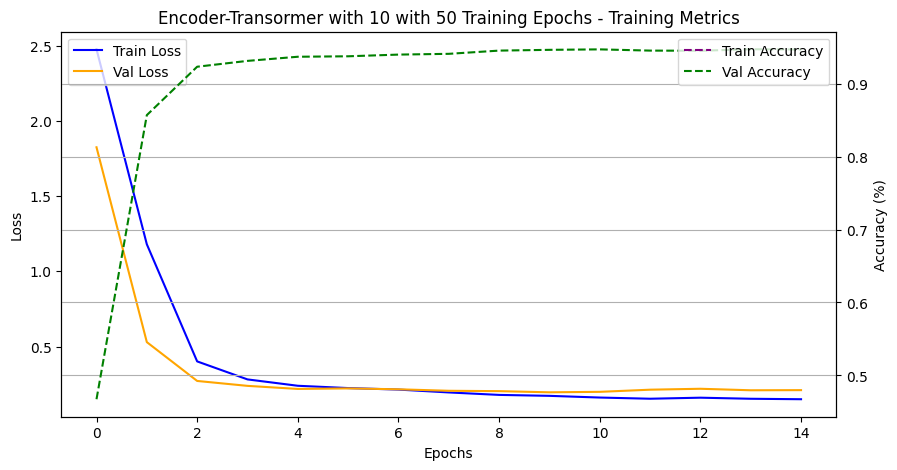


--- Training Cross-Attention Model for Seq Length: 10 ---
8705068
Time: 0.73s | Train Loss: 0.8767 | Val Loss: 0.0252 Val Accuracy: 0.9973
Time: 0.72s | Train Loss: 0.0142 | Val Loss: 0.0048 Val Accuracy: 1.0000
Time: 0.73s | Train Loss: 0.0047 | Val Loss: 0.0020 Val Accuracy: 1.0000
Time: 0.72s | Train Loss: 0.0032 | Val Loss: 0.0014 Val Accuracy: 1.0000
Time: 0.68s | Train Loss: 0.0024 | Val Loss: 0.0011 Val Accuracy: 1.0000
Time: 0.68s | Train Loss: 0.0020 | Val Loss: 0.0009 Val Accuracy: 1.0000
Time: 0.68s | Train Loss: 0.0017 | Val Loss: 0.0008 Val Accuracy: 1.0000
Time: 0.68s | Train Loss: 0.0014 | Val Loss: 0.0007 Val Accuracy: 1.0000
Time: 0.68s | Train Loss: 0.0012 | Val Loss: 0.0006 Val Accuracy: 1.0000
Time: 0.68s | Train Loss: 0.0011 | Val Loss: 0.0005 Val Accuracy: 1.0000
Time: 0.68s | Train Loss: 0.0010 | Val Loss: 0.0005 Val Accuracy: 1.0000
Early stopping triggered after 11 epochs (no improvement for 5 epochs). 
Best Val Loss: 0.0009, Current Val Loss: 0.0005
Average t

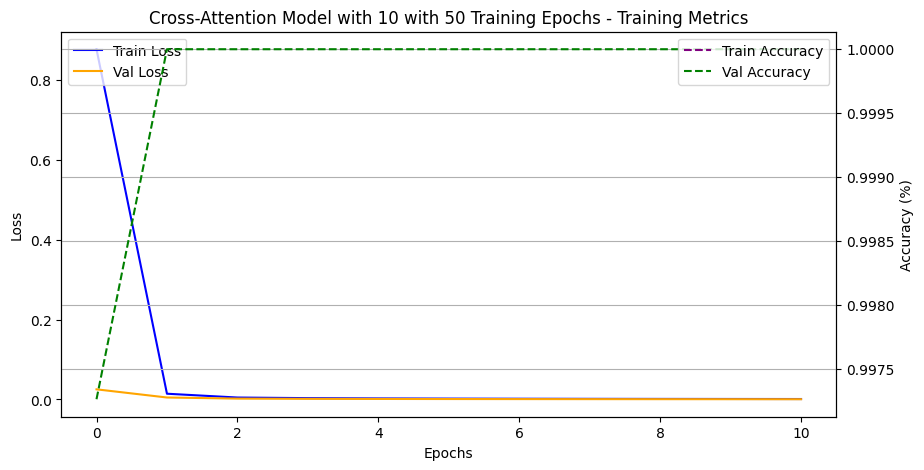


--- Training for Sequence Length: 20 ---
3967788
Time: 0.28s | Train Loss: 2.6474 | Val Loss: 2.1045 Val Accuracy: 0.3562
Time: 0.28s | Train Loss: 1.6208 | Val Loss: 0.8179 Val Accuracy: 0.7706
Time: 0.28s | Train Loss: 0.5099 | Val Loss: 0.1834 Val Accuracy: 0.9517
Time: 0.28s | Train Loss: 0.2026 | Val Loss: 0.1303 Val Accuracy: 0.9633
Time: 0.28s | Train Loss: 0.1440 | Val Loss: 0.1148 Val Accuracy: 0.9678
Time: 0.28s | Train Loss: 0.1226 | Val Loss: 0.1071 Val Accuracy: 0.9700
Time: 0.28s | Train Loss: 0.1068 | Val Loss: 0.1034 Val Accuracy: 0.9707
Time: 0.28s | Train Loss: 0.0983 | Val Loss: 0.0999 Val Accuracy: 0.9707
Time: 0.28s | Train Loss: 0.0905 | Val Loss: 0.0985 Val Accuracy: 0.9726
Time: 0.28s | Train Loss: 0.0826 | Val Loss: 0.1014 Val Accuracy: 0.9726
Time: 0.28s | Train Loss: 0.0787 | Val Loss: 0.1023 Val Accuracy: 0.9720
Time: 0.27s | Train Loss: 0.0770 | Val Loss: 0.1015 Val Accuracy: 0.9726
Time: 0.28s | Train Loss: 0.0733 | Val Loss: 0.1031 Val Accuracy: 0.9722
T

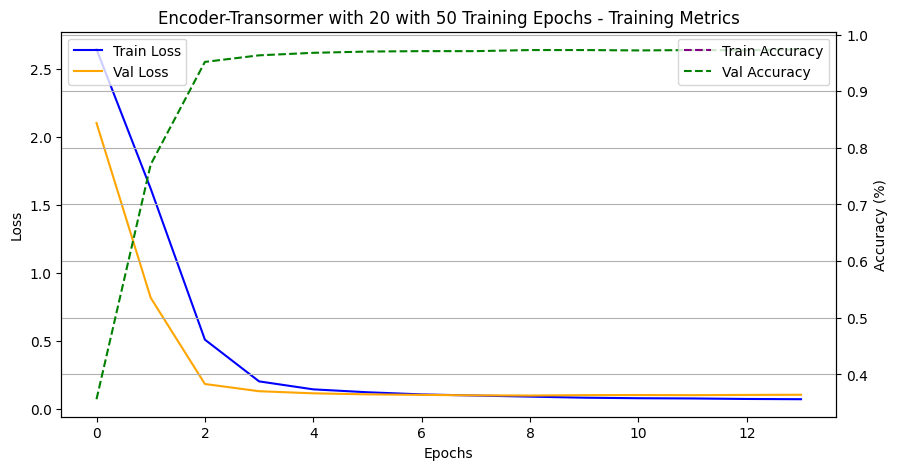


--- Training Cross-Attention Model for Seq Length: 20 ---
8705068
Time: 0.71s | Train Loss: 0.7928 | Val Loss: 0.0130 Val Accuracy: 1.0000
Time: 0.70s | Train Loss: 0.0105 | Val Loss: 0.0026 Val Accuracy: 1.0000
Time: 0.70s | Train Loss: 0.0040 | Val Loss: 0.0017 Val Accuracy: 1.0000
Time: 0.70s | Train Loss: 0.0029 | Val Loss: 0.0013 Val Accuracy: 1.0000
Time: 0.70s | Train Loss: 0.0023 | Val Loss: 0.0010 Val Accuracy: 1.0000
Time: 0.69s | Train Loss: 0.0018 | Val Loss: 0.0009 Val Accuracy: 1.0000
Time: 0.68s | Train Loss: 0.0015 | Val Loss: 0.0007 Val Accuracy: 1.0000
Time: 0.69s | Train Loss: 0.0013 | Val Loss: 0.0006 Val Accuracy: 1.0000
Time: 0.68s | Train Loss: 0.0011 | Val Loss: 0.0005 Val Accuracy: 1.0000
Time: 0.68s | Train Loss: 0.0010 | Val Loss: 0.0005 Val Accuracy: 1.0000
Time: 0.69s | Train Loss: 0.0009 | Val Loss: 0.0004 Val Accuracy: 1.0000
Time: 0.68s | Train Loss: 0.0008 | Val Loss: 0.0004 Val Accuracy: 1.0000
Time: 0.70s | Train Loss: 0.0007 | Val Loss: 0.0003 Val A

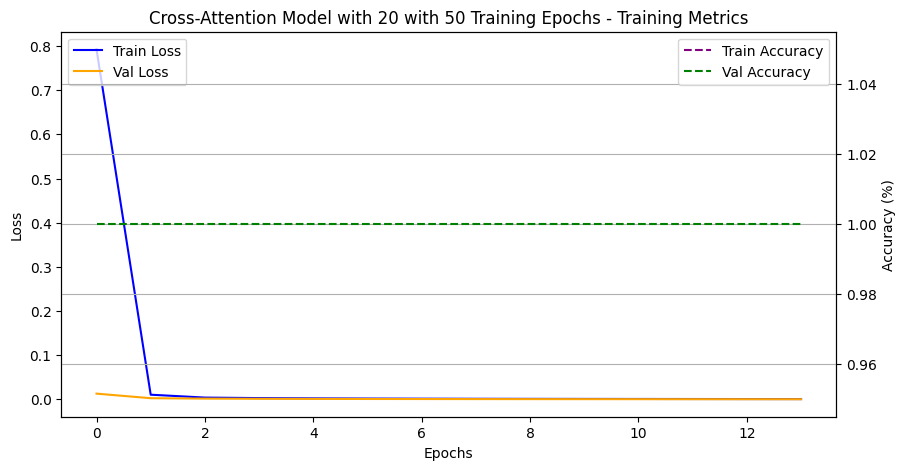


--- Training for Sequence Length: 30 ---
3967788
Time: 0.29s | Train Loss: 2.6089 | Val Loss: 2.1862 Val Accuracy: 0.3282
Time: 0.29s | Train Loss: 1.8498 | Val Loss: 1.1818 Val Accuracy: 0.6498
Time: 0.28s | Train Loss: 0.7260 | Val Loss: 0.2104 Val Accuracy: 0.9442
Time: 0.28s | Train Loss: 0.2422 | Val Loss: 0.1018 Val Accuracy: 0.9740
Time: 0.28s | Train Loss: 0.1396 | Val Loss: 0.0823 Val Accuracy: 0.9763
Time: 0.28s | Train Loss: 0.1066 | Val Loss: 0.0788 Val Accuracy: 0.9778
Time: 0.28s | Train Loss: 0.0899 | Val Loss: 0.0719 Val Accuracy: 0.9805
Time: 0.29s | Train Loss: 0.0828 | Val Loss: 0.0700 Val Accuracy: 0.9801
Time: 0.28s | Train Loss: 0.0735 | Val Loss: 0.0676 Val Accuracy: 0.9805
Time: 0.28s | Train Loss: 0.0674 | Val Loss: 0.0697 Val Accuracy: 0.9810
Time: 0.28s | Train Loss: 0.0636 | Val Loss: 0.0674 Val Accuracy: 0.9819
Time: 0.28s | Train Loss: 0.0612 | Val Loss: 0.0702 Val Accuracy: 0.9809
Time: 0.28s | Train Loss: 0.0556 | Val Loss: 0.0707 Val Accuracy: 0.9817
T

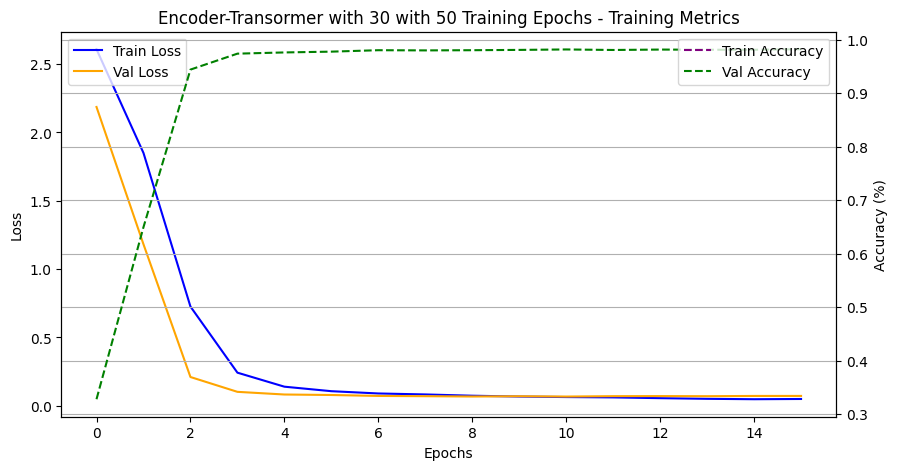


--- Training Cross-Attention Model for Seq Length: 30 ---
8705068
Time: 0.70s | Train Loss: 0.8848 | Val Loss: 0.0148 Val Accuracy: 0.9998
Time: 0.70s | Train Loss: 0.0109 | Val Loss: 0.0030 Val Accuracy: 1.0000
Time: 0.71s | Train Loss: 0.0044 | Val Loss: 0.0020 Val Accuracy: 1.0000
Time: 0.71s | Train Loss: 0.0032 | Val Loss: 0.0015 Val Accuracy: 1.0000
Time: 0.73s | Train Loss: 0.0025 | Val Loss: 0.0012 Val Accuracy: 1.0000
Time: 0.71s | Train Loss: 0.0020 | Val Loss: 0.0010 Val Accuracy: 1.0000
Time: 0.71s | Train Loss: 0.0017 | Val Loss: 0.0008 Val Accuracy: 1.0000
Time: 0.70s | Train Loss: 0.0014 | Val Loss: 0.0007 Val Accuracy: 1.0000
Time: 0.71s | Train Loss: 0.0012 | Val Loss: 0.0006 Val Accuracy: 1.0000
Time: 0.72s | Train Loss: 0.0011 | Val Loss: 0.0005 Val Accuracy: 1.0000
Time: 0.72s | Train Loss: 0.0010 | Val Loss: 0.0005 Val Accuracy: 1.0000
Time: 0.71s | Train Loss: 0.0009 | Val Loss: 0.0004 Val Accuracy: 1.0000
Time: 0.72s | Train Loss: 0.0008 | Val Loss: 0.0004 Val A

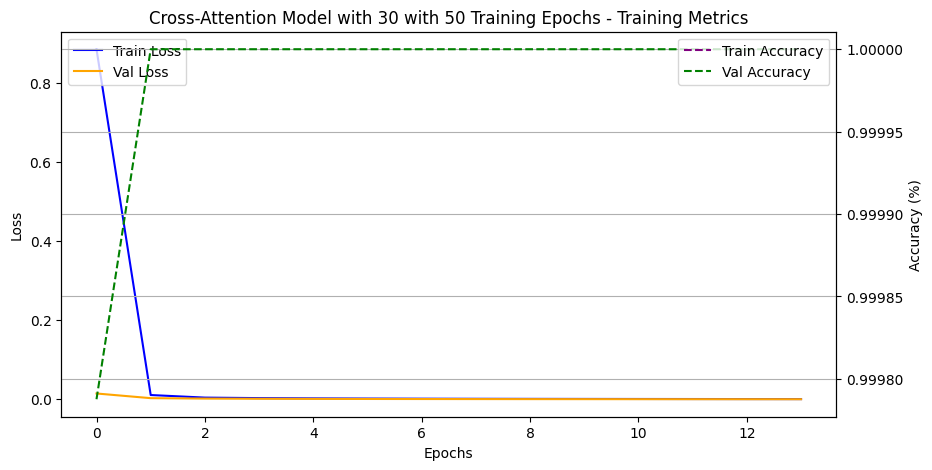

In [94]:
def train_cross_attention_model(seq_length, epochs=50, learning_rate=0.001, hidden_size= 128, n_layers=2, nhead=2, patience=5, min_delta=0.0005):
    print(f"\n--- Training Cross-Attention Model for Seq Length: {seq_length} ---")
    train_loader, val_loader = prepare_data(seq_length)
    # Model instantiation
    model = CharCrossAttention(len(chars), hidden_size=hidden_size, num_layers=n_layers, nhead=nhead).to(device)
    count_parameters(model)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    epoch_times = [] # Keep track of time per epoch

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        total_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            # The CharCrossAttention model expects both src and tgt inputs.
            # For training, src is batch_x and tgt is batch_y.
            output = model(batch_x, batch_y)
            loss = criterion(output.transpose(1, 2), batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss/len(train_loader))
        end_time = time.time()
        epoch_duration = end_time - start_time
        epoch_times.append(epoch_duration)

        # Validation
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                # The CharCrossAttention model expects both src and tgt inputs for validation.
                # Here, batch_x would be the source sequence and batch_y the target sequence.
                val_output = model(batch_x, batch_y)
                loss = criterion(val_output.transpose(1, 2), batch_y)
                val_loss += loss.item()
                _, predicted = torch.max(val_output, 2)
                total += batch_y.numel()
                correct += (predicted == batch_y).sum().item()

        current_val_loss = val_loss/len(val_loader)
        val_losses.append(current_val_loss)
        val_accuracies.append(correct/total)

        print(f"Time: {epoch_duration:.2f}s | Train Loss: {total_loss/len(train_loader):.4f} | Val Loss: {current_val_loss:.4f} Val Accuracy: {correct/total:.4f}")

        # Early stopping logic
        if current_val_loss < best_val_loss - min_delta:
            best_val_loss = current_val_loss
            patience_counter = 0
            best_model_state = model.state_dict() # Save best model state
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch + 1} epochs (no improvement for {patience} epochs). ")
                print(f"Best Val Loss: {best_val_loss:.4f}, Current Val Loss: {current_val_loss:.4f}")
                break # Break from the epoch loop

    if best_model_state:
        model.load_state_dict(best_model_state) # Load the best model found

    Average_Time = sum(epoch_times) / len(epoch_times)
    print(f"Average time per epoch: {Average_Time:.2f} seconds")
    # Use the appropriate prediction function for sequence-to-sequence models
    test_str = "This is a simple example to demonstrate how to predict the next char"
    predicted_char = predict_next_char_seq2seq(model, char_to_ix, ix_to_char, test_str,seq_length, device)
    print(f"Predicted next character: '{predicted_char}'")
    plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies, f"Cross-Attention Model with {seq_length} with {epochs} Training Epochs")

# Run for seq lengths 10, 20, 30
for sl in [10, 20, 30]:
    train_char_transformer(seq_length=sl, epochs=50, learning_rate=0.001, hidden_size= 256, n_layers=3, nhead=2)
    train_cross_attention_model(seq_length=sl, epochs=50, learning_rate=0.001, hidden_size= 256, n_layers=3, nhead=2)

In [9]:
# Step 1: Download the dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text  # This is the entire text data

# Step 2: Prepare the dataset
sequence_length = 20
# Create a character mapping to integers
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode the text into integers
encoded_text = [char_to_int[ch] for ch in text]

# Step 3: Create a dataset class
class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

def shakespeare_dataset(seq_length, batch_size):
    current_sequences = []
    current_targets = []
    for i in range(0, len(encoded_text) - seq_length - 1): # Adjusted loop range for target sequence
        seq = encoded_text[i:i + seq_length]
        target_seq = encoded_text[i+1:i + seq_length + 1] # Target is now a sequence
        current_sequences.append(seq)
        current_targets.append(target_seq)

    # Convert to PyTorch tensors
    current_sequences = torch.tensor(current_sequences, dtype=torch.long)
    current_targets = torch.tensor(current_targets, dtype=torch.long)

    # Dynamic loader assignment for specific sequence lengths
    ds = CharDataset(current_sequences, current_targets)
    train_size = int(len(ds) * 0.8)
    val_size = len(ds) - train_size
    train_ds, val_ds = random_split(ds, [train_size, val_size])

    t_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    v_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return t_loader, v_loader

def generate_text(model, start_str, length=100, seq_length=20, device='gpu'): # Changed default device to 'cpu'
    model.eval()
    generated = start_str

    # Ensure start_str is at least seq_length long for initial input, pad if necessary
    processed_start_str = start_str[-seq_length:] if len(start_str) > seq_length else start_str.ljust(seq_length, ' ')

    # Initial encoder input is the context
    src_input_list = [char_to_int[c] for c in processed_start_str]

    for _ in range(length):
        # For CharTransformer (encoder-only), we only pass the source sequence
        current_input_tensor = torch.tensor([src_input_list], dtype=torch.long).to(device)

        output = model(current_input_tensor)

        # The output is (batch_size, seq_len, vocab_size)
        # We want the prediction for the next character, which is at the last position of the sequence
        predicted_logits = output[:, -1, :]
        pred_idx = torch.argmax(predicted_logits, dim=-1).item()

        predicted_char = int_to_char[pred_idx]
        generated += predicted_char

        # Slide the window for the next iteration: add predicted char, remove oldest char
        src_input_list.append(pred_idx)
        src_input_list = src_input_list[1:]

    return generated

In [10]:
def train_shakesperetransformer(seq_length, epochs=50, learning_rate=0.001, d_model=512, num_heads=8, num_layers=6, batch_size=64,
                                title='Char Transformer Model', patience=5, min_delta=0.0005):
    print(f"\n--- Training Char Transformer for Seq Length: {seq_length} ---")
    train_loader, val_loader = shakespeare_dataset(seq_length, batch_size)
    # Correctly instantiate CharTransformer
    model = CharTransformer(vocab_size, d_model, vocab_size, num_layers, num_heads).to(device)
    count_parameters(model)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    epoch_times = [] # Keep track of time per epoch

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        total_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            # CharTransformer is encoder-only, so only pass batch_x
            output = model(batch_x)
            loss = criterion(output.transpose(1, 2), batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_losses.append(total_loss/len(train_loader))
        end_time = time.time()
        epoch_duration = end_time - start_time
        epoch_times.append(epoch_duration)

        model.eval()
        total_val_loss = 0
        correct_predictions = 0
        total_predictions = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                # CharTransformer is encoder-only, so only pass batch_x
                val_output = model(batch_x)
                val_loss = criterion(val_output.transpose(1, 2), batch_y)
                total_val_loss += val_loss.item()

                # Calculate accuracy
                _, predicted = torch.max(val_output, 2)
                total_predictions += batch_y.numel()
                correct_predictions += (predicted == batch_y).sum().item()

        current_val_loss = total_val_loss/len(val_loader)
        val_losses.append(current_val_loss)
        val_accuracies.append(correct_predictions/total_predictions)
        avg_val_loss = current_val_loss
        perplexity = np.exp(avg_val_loss)
        print(f"Time: {epoch_duration:.2f}s | Train Loss: {total_loss/len(train_loader):.4f} | Val Loss: {avg_val_loss:.4f} Val Accuracy: {correct_predictions/total_predictions:.4f}")

        # Early stopping logic
        if current_val_loss < best_val_loss - min_delta:
            best_val_loss = current_val_loss
            patience_counter = 0
            best_model_state = model.state_dict() # Save best model state
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch + 1} epochs (no improvement for {patience} epochs).")
                break # Break from the epoch loop

    if best_model_state:
        model.load_state_dict(best_model_state) # Load the best model found

    Average_Time = sum(epoch_times) / len(epoch_times)
    print(f"Average time per epoch: {Average_Time:.2f} seconds")

    # Generate an output sequence using the now compatible generate_text
    sample_seed = text[:seq_length] if len(text) > seq_length else "FIRST CITIZEN:"[:seq_length]
    generated_sample = generate_text(model, sample_seed, length=60, seq_length=seq_length, device=device)

    print(f"  Execution Time: {sum(epoch_times):.2f}s | PPL: {perplexity:.2f}")
    print(f"  Generated Text Sample:\n  \" {generated_sample.replace('\n', ' ')} \"")
    plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies, title)

Training Config: Blocks=1, Heads=2

--- Training Char Transformer for Seq Length: 20 ---
1348417
Time: 21.47s | Train Loss: 0.1616 | Val Loss: 0.0931 Val Accuracy: 0.9724
Time: 21.93s | Train Loss: 0.1049 | Val Loss: 0.0868 Val Accuracy: 0.9740
Time: 21.89s | Train Loss: 0.0987 | Val Loss: 0.0837 Val Accuracy: 0.9745
Time: 22.18s | Train Loss: 0.0952 | Val Loss: 0.0826 Val Accuracy: 0.9749
Time: 22.20s | Train Loss: 0.0928 | Val Loss: 0.0804 Val Accuracy: 0.9755
Average time per epoch: 21.94 seconds
  Execution Time: 109.68s | PPL: 1.08
  Generated Text Sample:
  " First Citizen: Before the shall the shall the shall the shall the shall the shal "


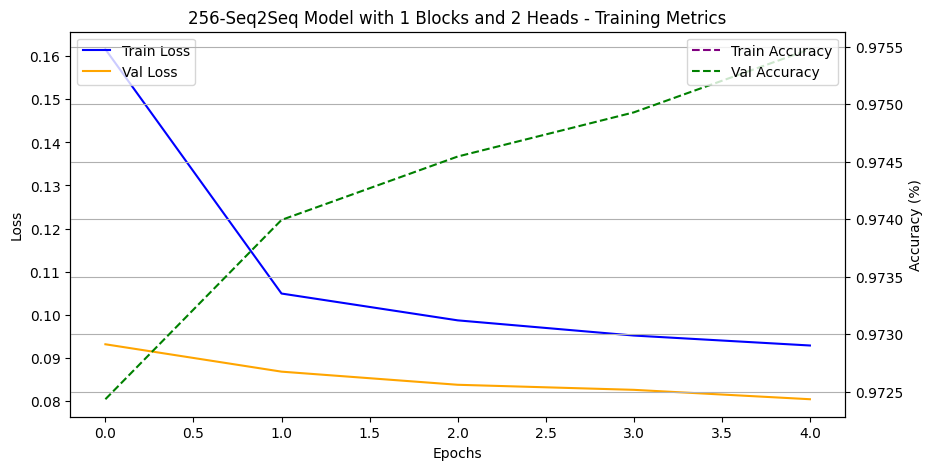




--- Training Char Transformer for Seq Length: 20 ---
609729
Time: 19.16s | Train Loss: 0.1881 | Val Loss: 0.0923 Val Accuracy: 0.9724
Time: 19.47s | Train Loss: 0.1046 | Val Loss: 0.0863 Val Accuracy: 0.9741
Time: 19.23s | Train Loss: 0.0985 | Val Loss: 0.0838 Val Accuracy: 0.9747
Time: 19.11s | Train Loss: 0.0952 | Val Loss: 0.0815 Val Accuracy: 0.9752
Time: 19.67s | Train Loss: 0.0929 | Val Loss: 0.0805 Val Accuracy: 0.9755
Average time per epoch: 19.33 seconds
  Execution Time: 96.64s | PPL: 1.08
  Generated Text Sample:
  " First Citizen: Before the the the the strue the the the strue the the the strue  "


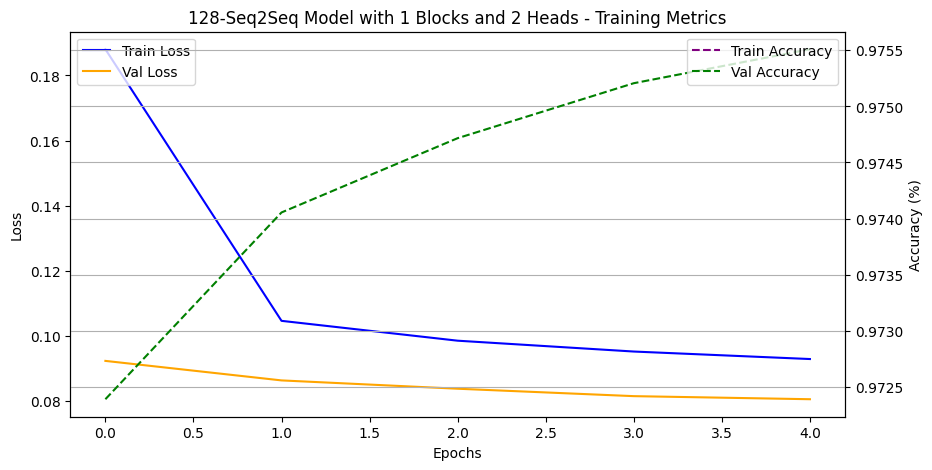



Training Config: Blocks=1, Heads=4

--- Training Char Transformer for Seq Length: 20 ---
1348417
Time: 21.28s | Train Loss: 0.1445 | Val Loss: 0.0896 Val Accuracy: 0.9731
Time: 21.75s | Train Loss: 0.0912 | Val Loss: 0.0846 Val Accuracy: 0.9745
Time: 22.03s | Train Loss: 0.0875 | Val Loss: 0.0815 Val Accuracy: 0.9753
Time: 22.06s | Train Loss: 0.0851 | Val Loss: 0.0796 Val Accuracy: 0.9755
Time: 22.08s | Train Loss: 0.0837 | Val Loss: 0.0785 Val Accuracy: 0.9760
Average time per epoch: 21.84 seconds
  Execution Time: 109.18s | PPL: 1.08
  Generated Text Sample:
  " First Citizen: Before the world the world the world the world the world the worl "


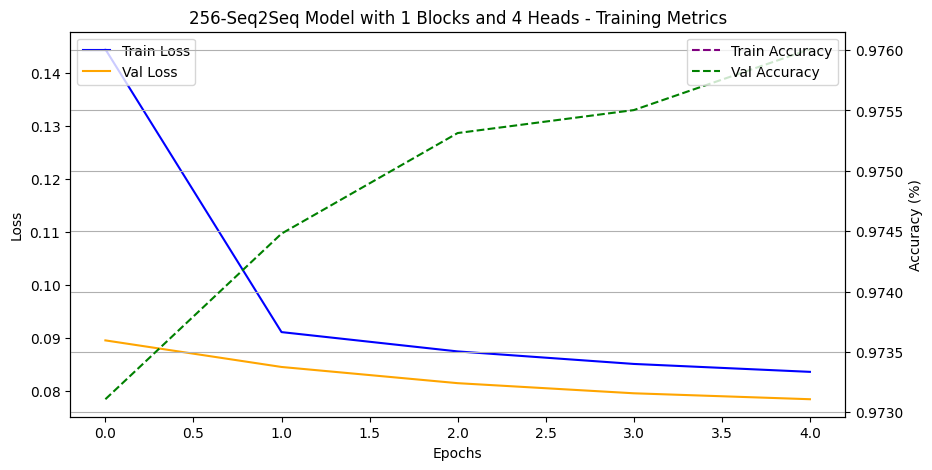




--- Training Char Transformer for Seq Length: 20 ---
609729
Time: 19.22s | Train Loss: 0.1780 | Val Loss: 0.0897 Val Accuracy: 0.9733
Time: 19.32s | Train Loss: 0.0917 | Val Loss: 0.0836 Val Accuracy: 0.9748
Time: 19.23s | Train Loss: 0.0870 | Val Loss: 0.0811 Val Accuracy: 0.9753
Time: 19.51s | Train Loss: 0.0846 | Val Loss: 0.0791 Val Accuracy: 0.9758
Time: 19.69s | Train Loss: 0.0829 | Val Loss: 0.0777 Val Accuracy: 0.9763
Average time per epoch: 19.39 seconds
  Execution Time: 96.97s | PPL: 1.08
  Generated Text Sample:
  " First Citizen: Before the shall the shall the shall the shall the shall the shal "


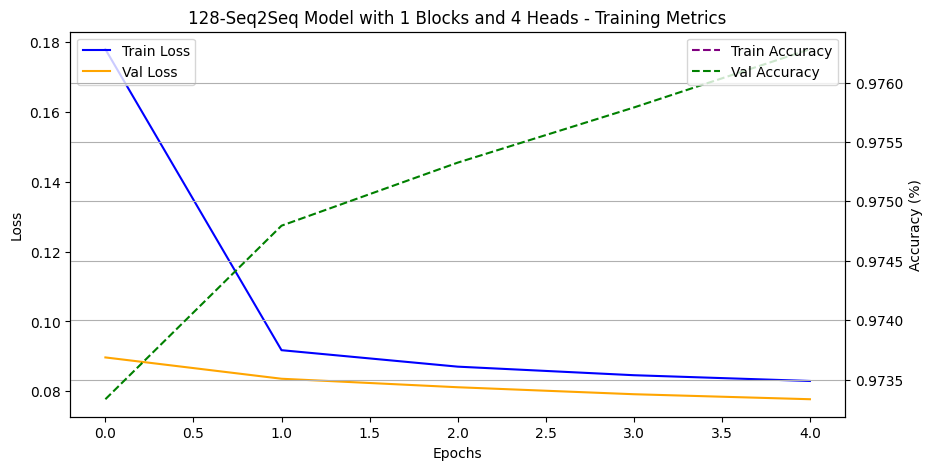



Training Config: Blocks=2, Heads=2

--- Training Char Transformer for Seq Length: 20 ---
2663489
Time: 34.71s | Train Loss: 0.1400 | Val Loss: 0.0872 Val Accuracy: 0.9739
Time: 34.84s | Train Loss: 0.0905 | Val Loss: 0.0830 Val Accuracy: 0.9749
Time: 34.98s | Train Loss: 0.0863 | Val Loss: 0.0797 Val Accuracy: 0.9757
Time: 35.39s | Train Loss: 0.0838 | Val Loss: 0.0777 Val Accuracy: 0.9763
Time: 35.27s | Train Loss: 0.0818 | Val Loss: 0.0763 Val Accuracy: 0.9767
Average time per epoch: 35.04 seconds
  Execution Time: 175.19s | PPL: 1.08
  Generated Text Sample:
  " First Citizen: Before the shall be the shall be the shall be the shall be the sh "


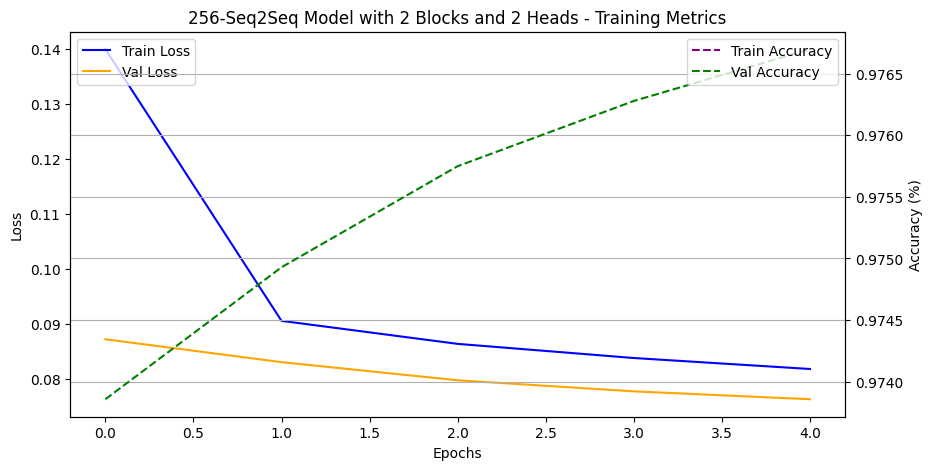




--- Training Char Transformer for Seq Length: 20 ---
1202753
Time: 26.91s | Train Loss: 0.1639 | Val Loss: 0.0891 Val Accuracy: 0.9731
Time: 27.09s | Train Loss: 0.0914 | Val Loss: 0.0827 Val Accuracy: 0.9750
Time: 27.25s | Train Loss: 0.0860 | Val Loss: 0.0791 Val Accuracy: 0.9759
Time: 27.47s | Train Loss: 0.0830 | Val Loss: 0.0773 Val Accuracy: 0.9764
Time: 27.36s | Train Loss: 0.0811 | Val Loss: 0.0751 Val Accuracy: 0.9769
Average time per epoch: 27.22 seconds
  Execution Time: 136.08s | PPL: 1.08
  Generated Text Sample:
  " First Citizen: Before the some the some to the some to the some to the some to t "


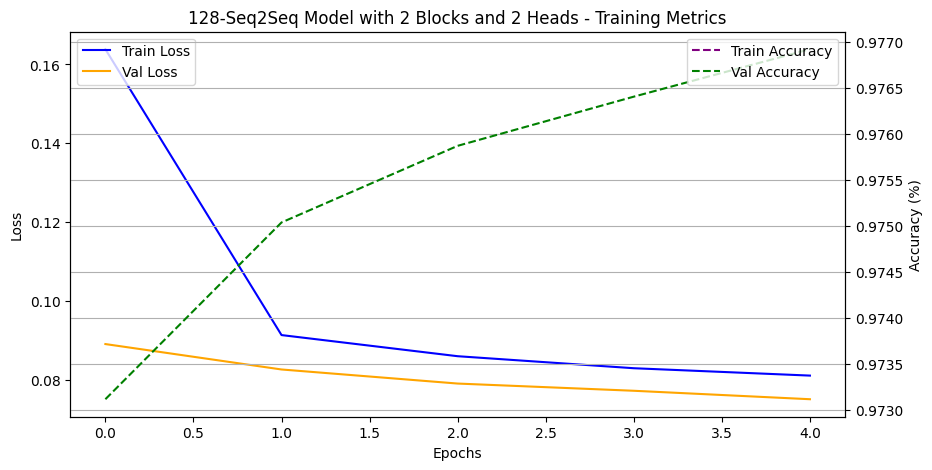



Training Config: Blocks=2, Heads=4

--- Training Char Transformer for Seq Length: 20 ---
2663489
Time: 34.19s | Train Loss: 0.1390 | Val Loss: 0.0868 Val Accuracy: 0.9740
Time: 34.45s | Train Loss: 0.0876 | Val Loss: 0.0811 Val Accuracy: 0.9754
Time: 34.46s | Train Loss: 0.0832 | Val Loss: 0.0790 Val Accuracy: 0.9761
Time: 34.81s | Train Loss: 0.0807 | Val Loss: 0.0760 Val Accuracy: 0.9767
Time: 34.70s | Train Loss: 0.0790 | Val Loss: 0.0749 Val Accuracy: 0.9770
Average time per epoch: 34.52 seconds
  Execution Time: 172.60s | PPL: 1.08
  Generated Text Sample:
  " First Citizen: Before the stree the stree the stree the stree the stree the stre "


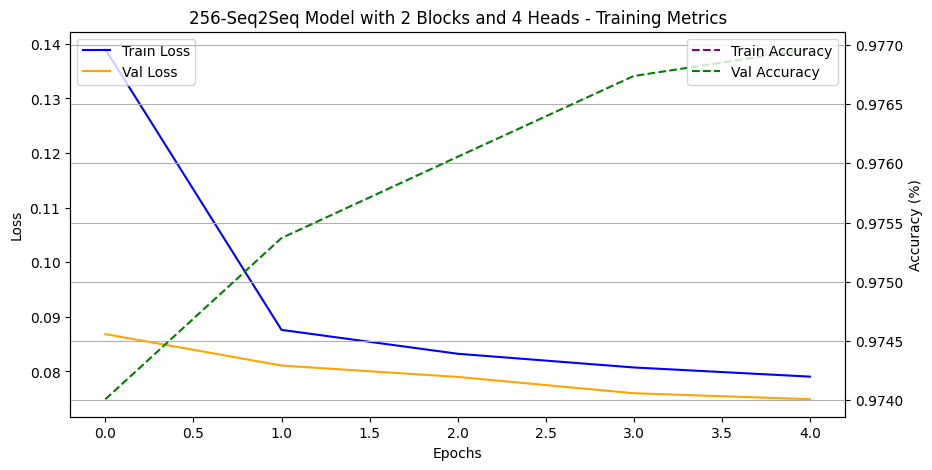




--- Training Char Transformer for Seq Length: 20 ---
1202753
Time: 26.77s | Train Loss: 0.1638 | Val Loss: 0.0884 Val Accuracy: 0.9734
Time: 27.51s | Train Loss: 0.0884 | Val Loss: 0.0811 Val Accuracy: 0.9754
Time: 27.23s | Train Loss: 0.0837 | Val Loss: 0.0789 Val Accuracy: 0.9759
Time: 27.45s | Train Loss: 0.0809 | Val Loss: 0.0763 Val Accuracy: 0.9766
Time: 27.23s | Train Loss: 0.0791 | Val Loss: 0.0745 Val Accuracy: 0.9771
Average time per epoch: 27.24 seconds
  Execution Time: 136.19s | PPL: 1.08
  Generated Text Sample:
  " First Citizen: Before the seat the seat the seat the seat the seat the seat the  "


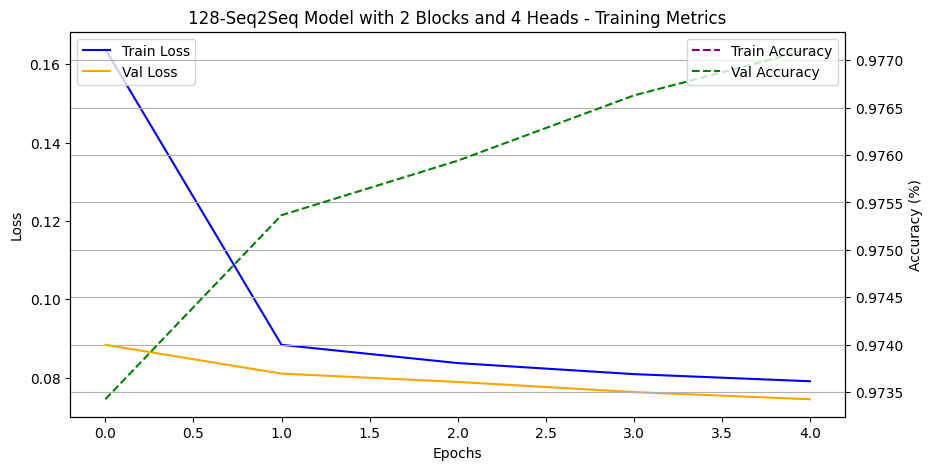



Training Config: Blocks=4, Heads=2

--- Training Char Transformer for Seq Length: 20 ---
5293633
Time: 60.51s | Train Loss: 0.1679 | Val Loss: 0.0862 Val Accuracy: 0.9741
Time: 60.85s | Train Loss: 0.0889 | Val Loss: 0.0819 Val Accuracy: 0.9752
Time: 60.91s | Train Loss: 0.0843 | Val Loss: 0.0778 Val Accuracy: 0.9762
Time: 61.20s | Train Loss: 0.0819 | Val Loss: 0.0761 Val Accuracy: 0.9765
Time: 61.09s | Train Loss: 0.0801 | Val Loss: 0.0749 Val Accuracy: 0.9770
Average time per epoch: 60.91 seconds
  Execution Time: 304.55s | PPL: 1.08
  Generated Text Sample:
  " First Citizen: Before the sons and the sons and the sons and the sons and the so "


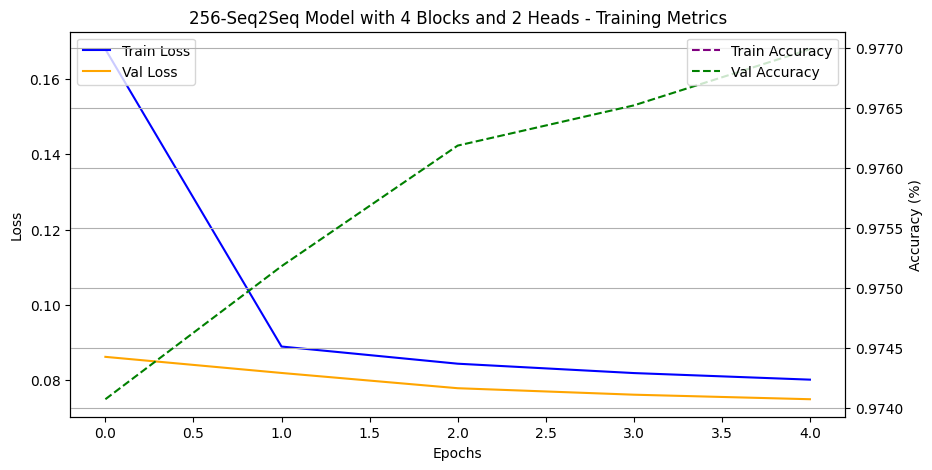




--- Training Char Transformer for Seq Length: 20 ---
2388801
Time: 43.53s | Train Loss: 0.1685 | Val Loss: 0.0863 Val Accuracy: 0.9741
Time: 43.61s | Train Loss: 0.0880 | Val Loss: 0.0820 Val Accuracy: 0.9752
Time: 43.21s | Train Loss: 0.0839 | Val Loss: 0.0783 Val Accuracy: 0.9760
Time: 43.32s | Train Loss: 0.0814 | Val Loss: 0.0763 Val Accuracy: 0.9765
Time: 43.11s | Train Loss: 0.0796 | Val Loss: 0.0749 Val Accuracy: 0.9770
Average time per epoch: 43.36 seconds
  Execution Time: 216.79s | PPL: 1.08
  Generated Text Sample:
  " First Citizen: Before the come to the come to the come to the come to the come t "


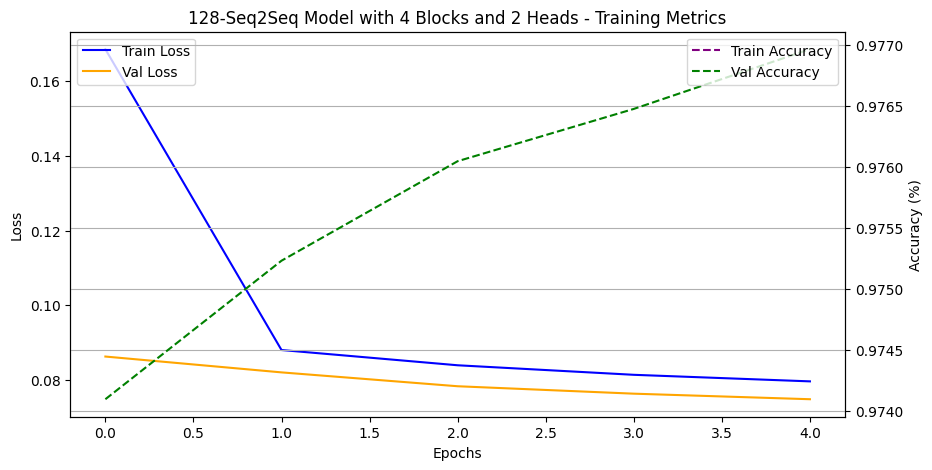



Training Config: Blocks=4, Heads=4

--- Training Char Transformer for Seq Length: 20 ---
5293633
Time: 59.32s | Train Loss: 0.2106 | Val Loss: 0.0854 Val Accuracy: 0.9743
Time: 60.14s | Train Loss: 0.0871 | Val Loss: 0.0806 Val Accuracy: 0.9756
Time: 60.37s | Train Loss: 0.0831 | Val Loss: 0.0782 Val Accuracy: 0.9761
Time: 60.04s | Train Loss: 0.0804 | Val Loss: 0.0749 Val Accuracy: 0.9770
Time: 60.01s | Train Loss: 0.0786 | Val Loss: 0.0751 Val Accuracy: 0.9770
Average time per epoch: 59.97 seconds
  Execution Time: 299.87s | PPL: 1.08
  Generated Text Sample:
  " First Citizen: Before the world the world the world the world the world the worl "


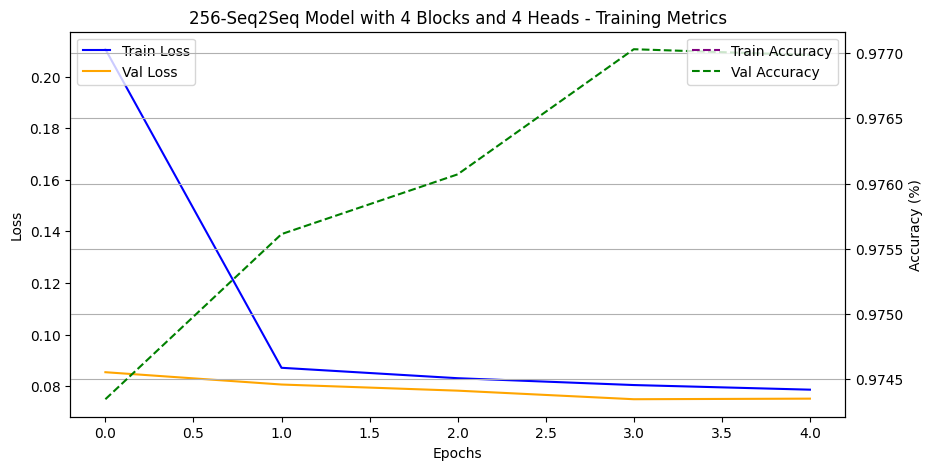




--- Training Char Transformer for Seq Length: 20 ---
2388801
Time: 42.67s | Train Loss: 0.1618 | Val Loss: 0.0856 Val Accuracy: 0.9738
Time: 42.97s | Train Loss: 0.0870 | Val Loss: 0.0804 Val Accuracy: 0.9756
Time: 43.20s | Train Loss: 0.0830 | Val Loss: 0.0779 Val Accuracy: 0.9761
Time: 43.36s | Train Loss: 0.0807 | Val Loss: 0.0755 Val Accuracy: 0.9768


In [ ]:
blocks = [1, 2, 4]
heads = [2, 4]

for b in blocks:
    for h in heads:
        print(f"Training Config: Blocks={b}, Heads={h}")
        train_shakesperetransformer(seq_length=20, epochs=5, learning_rate=0.001, d_model=256, num_heads=h, num_layers=b, batch_size=256, title=f"256-Seq2Seq Model with {b} Blocks and {h} Heads")
        print("\n")
        train_shakesperetransformer(seq_length=20, epochs=5, learning_rate=0.001, d_model=128, num_heads=h, num_layers=b, batch_size=256, title=f"128-Seq2Seq Model with {b} Blocks and {h} Heads")
        print("\n")


Training Config: Blocks=4, Heads=4

--- Training Char Transformer for Seq Length: 20 ---
5293633
Time: 59.59s | Train Loss: 0.1643 | Val Loss: 0.0844 Val Accuracy: 0.9747
Time: 59.34s | Train Loss: 0.0872 | Val Loss: 0.0802 Val Accuracy: 0.9756
Time: 59.30s | Train Loss: 0.0831 | Val Loss: 0.0780 Val Accuracy: 0.9761
Time: 59.11s | Train Loss: 0.0804 | Val Loss: 0.0758 Val Accuracy: 0.9768
Time: 59.32s | Train Loss: 0.0785 | Val Loss: 0.0740 Val Accuracy: 0.9772
Average time per epoch: 59.33 seconds
  Execution Time: 296.65s | PPL: 1.08
  Generated Text Sample:
  " First Citizen: Before, that the compass of the courted the courted the courted t "


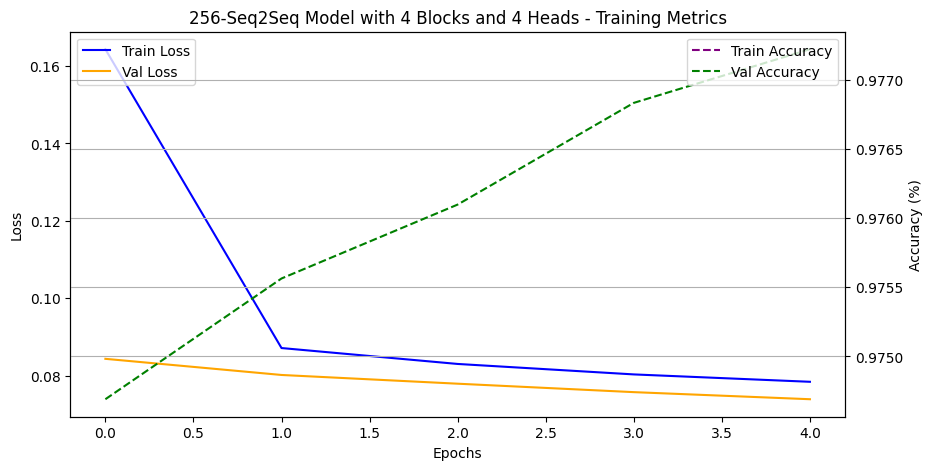




--- Training Char Transformer for Seq Length: 20 ---
2388801
Time: 41.78s | Train Loss: 0.1614 | Val Loss: 0.0856 Val Accuracy: 0.9744
Time: 42.43s | Train Loss: 0.0867 | Val Loss: 0.0807 Val Accuracy: 0.9754
Time: 42.32s | Train Loss: 0.0826 | Val Loss: 0.0782 Val Accuracy: 0.9762
Time: 42.58s | Train Loss: 0.0804 | Val Loss: 0.0763 Val Accuracy: 0.9766
Time: 42.39s | Train Loss: 0.0789 | Val Loss: 0.0751 Val Accuracy: 0.9769
Average time per epoch: 42.30 seconds
  Execution Time: 211.50s | PPL: 1.08
  Generated Text Sample:
  " First Citizen: Before the shall be some to the seal the seal the seal the seal t "


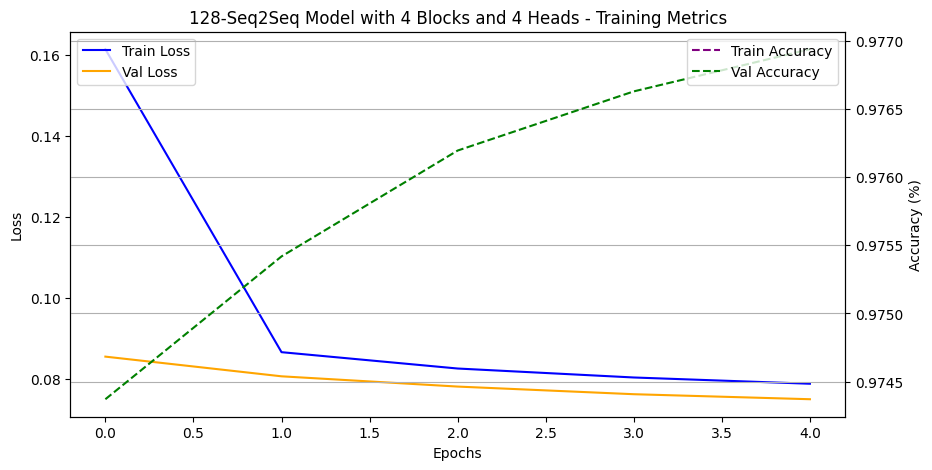

In [11]:
blocks = [4]
heads = [4]

for b in blocks:
    for h in heads:
        print(f"Training Config: Blocks={b}, Heads={h}")
        train_shakesperetransformer(seq_length=20, epochs=5, learning_rate=0.001, d_model=256, num_heads=h, num_layers=b, batch_size=256, title=f"256-Seq2Seq Model with {b} Blocks and {h} Heads")
        print("\n")
        train_shakesperetransformer(seq_length=20, epochs=5, learning_rate=0.001, d_model=128, num_heads=h, num_layers=b, batch_size=256, title=f"128-Seq2Seq Model with {b} Blocks and {h} Heads")
        print("\n")


Training Config: Blocks=1, Heads=2

--- Training Char Transformer for Seq Length: 30 ---
609729
Time: 18.87s | Train Loss: 0.1646 | Val Loss: 0.0630 Val Accuracy: 0.9812
Time: 19.35s | Train Loss: 0.0726 | Val Loss: 0.0582 Val Accuracy: 0.9826
Time: 19.42s | Train Loss: 0.0677 | Val Loss: 0.0560 Val Accuracy: 0.9831
Time: 19.64s | Train Loss: 0.0649 | Val Loss: 0.0545 Val Accuracy: 0.9835
Time: 19.56s | Train Loss: 0.0632 | Val Loss: 0.0539 Val Accuracy: 0.9837
Average time per epoch: 19.37 seconds
  Execution Time: 96.85s | PPL: 1.06
  Generated Text Sample:
  " First Citizen: Before we proces the with the with the with the with the with the with the  "


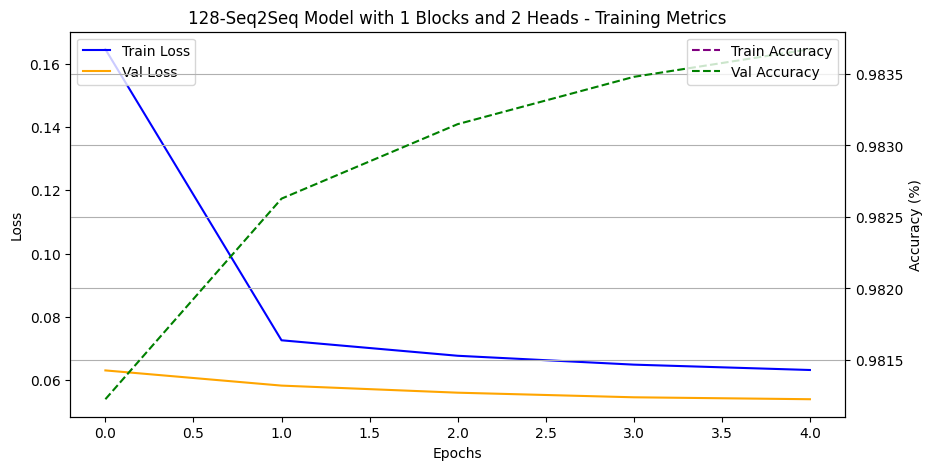



Training Config: Blocks=1, Heads=4

--- Training Char Transformer for Seq Length: 30 ---
609729
Time: 19.49s | Train Loss: 0.1544 | Val Loss: 0.0605 Val Accuracy: 0.9821
Time: 19.70s | Train Loss: 0.0614 | Val Loss: 0.0559 Val Accuracy: 0.9832
Time: 19.46s | Train Loss: 0.0583 | Val Loss: 0.0539 Val Accuracy: 0.9837
Time: 19.52s | Train Loss: 0.0565 | Val Loss: 0.0527 Val Accuracy: 0.9841
Time: 19.69s | Train Loss: 0.0554 | Val Loss: 0.0518 Val Accuracy: 0.9843
Average time per epoch: 19.57 seconds
  Execution Time: 97.87s | PPL: 1.05
  Generated Text Sample:
  " First Citizen: Before we proces the shall the shall the shall the shall the shall the shal "


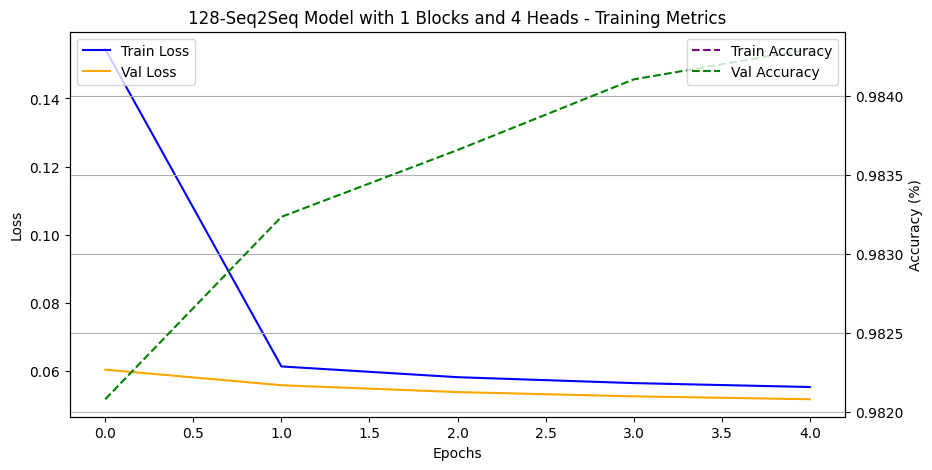



Training Config: Blocks=2, Heads=2

--- Training Char Transformer for Seq Length: 30 ---
1202753
Time: 28.66s | Train Loss: 0.1392 | Val Loss: 0.0593 Val Accuracy: 0.9825
Time: 29.04s | Train Loss: 0.0608 | Val Loss: 0.0547 Val Accuracy: 0.9836
Time: 29.32s | Train Loss: 0.0572 | Val Loss: 0.0523 Val Accuracy: 0.9842
Time: 29.25s | Train Loss: 0.0552 | Val Loss: 0.0510 Val Accuracy: 0.9845
Time: 29.10s | Train Loss: 0.0539 | Val Loss: 0.0499 Val Accuracy: 0.9848
Average time per epoch: 29.07 seconds
  Execution Time: 145.37s | PPL: 1.05
  Generated Text Sample:
  " First Citizen: Before we proceed the come the come the come the come the come the come the "


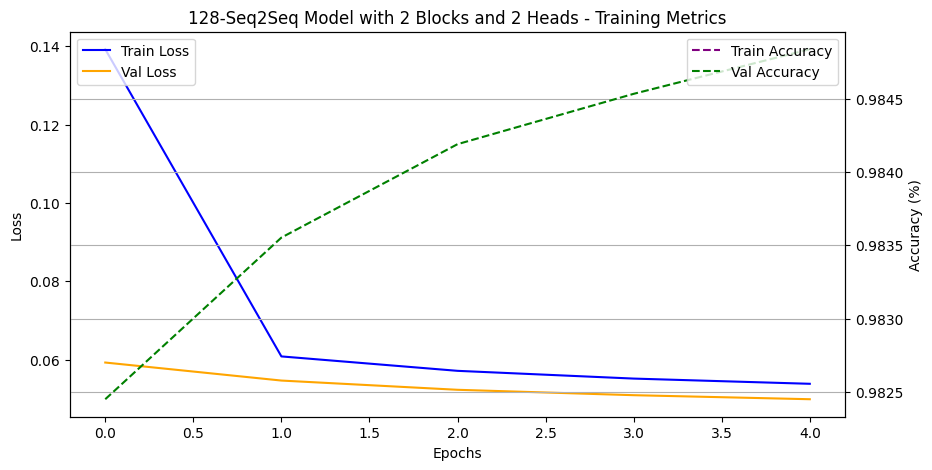



Training Config: Blocks=2, Heads=4

--- Training Char Transformer for Seq Length: 30 ---
1202753
Time: 29.03s | Train Loss: 0.1416 | Val Loss: 0.0587 Val Accuracy: 0.9825
Time: 29.23s | Train Loss: 0.0589 | Val Loss: 0.0539 Val Accuracy: 0.9837
Time: 29.64s | Train Loss: 0.0556 | Val Loss: 0.0518 Val Accuracy: 0.9843
Time: 29.41s | Train Loss: 0.0538 | Val Loss: 0.0505 Val Accuracy: 0.9846
Time: 29.64s | Train Loss: 0.0526 | Val Loss: 0.0495 Val Accuracy: 0.9848
Average time per epoch: 29.39 seconds
  Execution Time: 146.95s | PPL: 1.05
  Generated Text Sample:
  " First Citizen: Before we proceed the country the country the country the country the count "


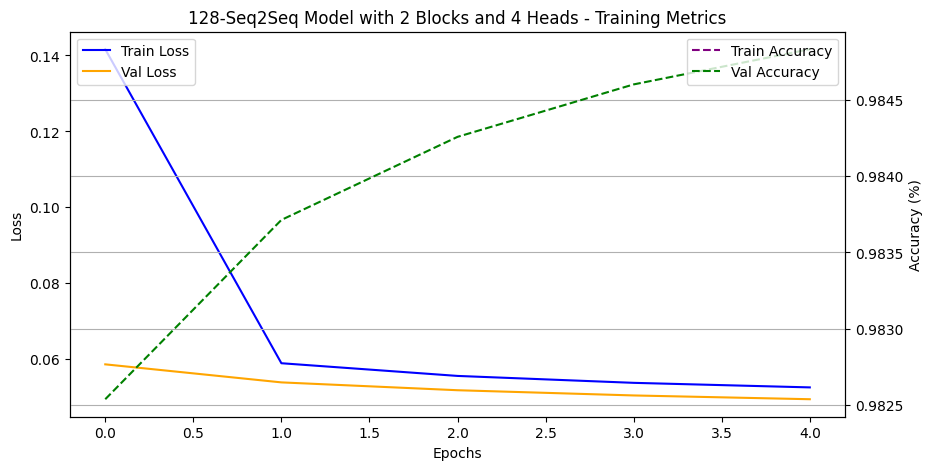



Training Config: Blocks=4, Heads=2

--- Training Char Transformer for Seq Length: 30 ---
2388801
Time: 48.23s | Train Loss: 0.1363 | Val Loss: 0.0581 Val Accuracy: 0.9826
Time: 48.65s | Train Loss: 0.0594 | Val Loss: 0.0547 Val Accuracy: 0.9834
Time: 48.91s | Train Loss: 0.0566 | Val Loss: 0.0527 Val Accuracy: 0.9840
Time: 49.05s | Train Loss: 0.0549 | Val Loss: 0.0513 Val Accuracy: 0.9843
Time: 48.81s | Train Loss: 0.0538 | Val Loss: 0.0508 Val Accuracy: 0.9845
Average time per epoch: 48.73 seconds
  Execution Time: 243.65s | PPL: 1.05
  Generated Text Sample:
  " First Citizen: Before we proce the shall be the could the sea the could the shall be the s "


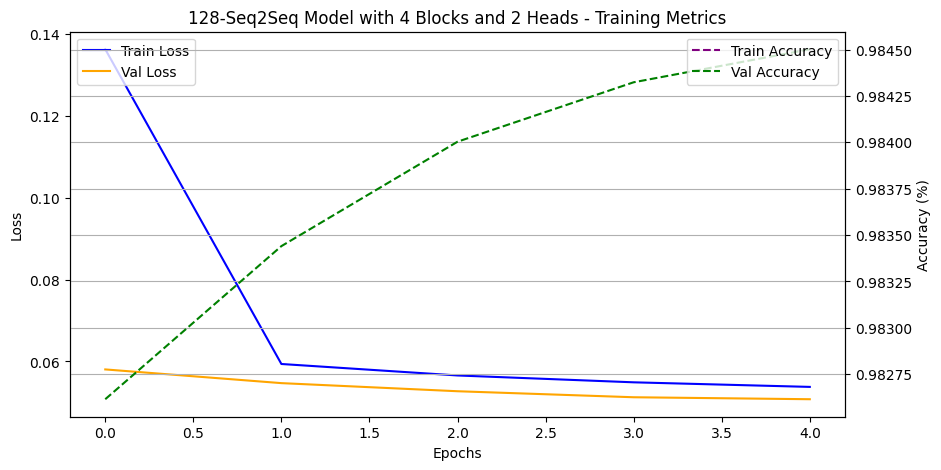



Training Config: Blocks=4, Heads=4

--- Training Char Transformer for Seq Length: 30 ---
2388801
Time: 49.01s | Train Loss: 0.1463 | Val Loss: 0.0570 Val Accuracy: 0.9829
Time: 49.21s | Train Loss: 0.0580 | Val Loss: 0.0538 Val Accuracy: 0.9837
Time: 49.49s | Train Loss: 0.0553 | Val Loss: 0.0518 Val Accuracy: 0.9841
Time: 49.51s | Train Loss: 0.0537 | Val Loss: 0.0508 Val Accuracy: 0.9845
Time: 49.75s | Train Loss: 0.0528 | Val Loss: 0.0502 Val Accuracy: 0.9846
Average time per epoch: 49.39 seconds
  Execution Time: 246.97s | PPL: 1.05
  Generated Text Sample:
  " First Citizen: Before we proceed the should to the soul so so soul so so so so so so so so "


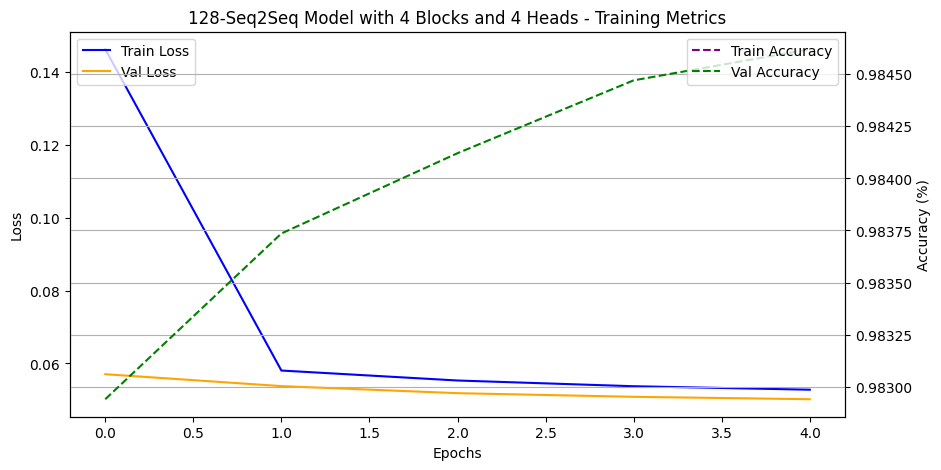



Training Config: Blocks=2, Heads=2

--- Training Char Transformer for Seq Length: 30 ---
2663489
Time: 47.00s | Train Loss: 0.1131 | Val Loss: 0.0592 Val Accuracy: 0.9825
Time: 47.15s | Train Loss: 0.0612 | Val Loss: 0.0551 Val Accuracy: 0.9834
Time: 47.29s | Train Loss: 0.0579 | Val Loss: 0.0531 Val Accuracy: 0.9839
Time: 47.61s | Train Loss: 0.0557 | Val Loss: 0.0517 Val Accuracy: 0.9843
Time: 47.63s | Train Loss: 0.0542 | Val Loss: 0.0505 Val Accuracy: 0.9846
Average time per epoch: 47.34 seconds
  Execution Time: 236.68s | PPL: 1.05
  Generated Text Sample:
  " First Citizen: Before we proce the shall be the shall be the shall be the shall be the sha "


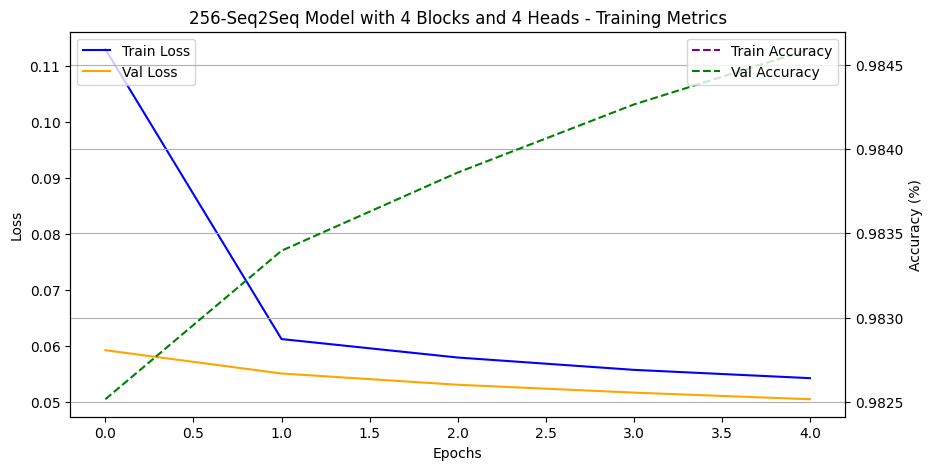

In [12]:
#seq 30
blocks = [1, 2, 4]
heads = [2, 4]

for b in blocks:
    for h in heads:
        print(f"Training Config: Blocks={b}, Heads={h}")
        train_shakesperetransformer(seq_length=30, epochs=5, learning_rate=0.001, d_model=128, num_heads=h, num_layers=b, batch_size=256, title=f"128-Seq2Seq Model with {b} Blocks and {h} Heads")
        print("\n")
print(f"Training Config: Blocks=2, Heads=2")
train_shakesperetransformer(seq_length=30, epochs=5, learning_rate=0.001, d_model=256, num_heads=2, num_layers=2, batch_size=256, title=f"256-Seq2Seq Model with 2 Blocks and 2 Heads")
print("\n")

Training Config: Blocks=1, Heads=2

--- Training Char Transformer for Seq Length: 50 ---
609729
Time: 24.72s | Train Loss: 0.1510 | Val Loss: 0.0381 Val Accuracy: 0.9888
Time: 24.85s | Train Loss: 0.0459 | Val Loss: 0.0359 Val Accuracy: 0.9894
Time: 24.79s | Train Loss: 0.0423 | Val Loss: 0.0343 Val Accuracy: 0.9898
Time: 25.05s | Train Loss: 0.0404 | Val Loss: 0.0331 Val Accuracy: 0.9900
Time: 24.96s | Train Loss: 0.0391 | Val Loss: 0.0327 Val Accuracy: 0.9901
Average time per epoch: 24.87 seconds
  Execution Time: 124.37s | PPL: 1.03
  Generated Text Sample:
  " First Citizen: Before we proceed any further, hear the the the the the the end the end the end the enever the  "


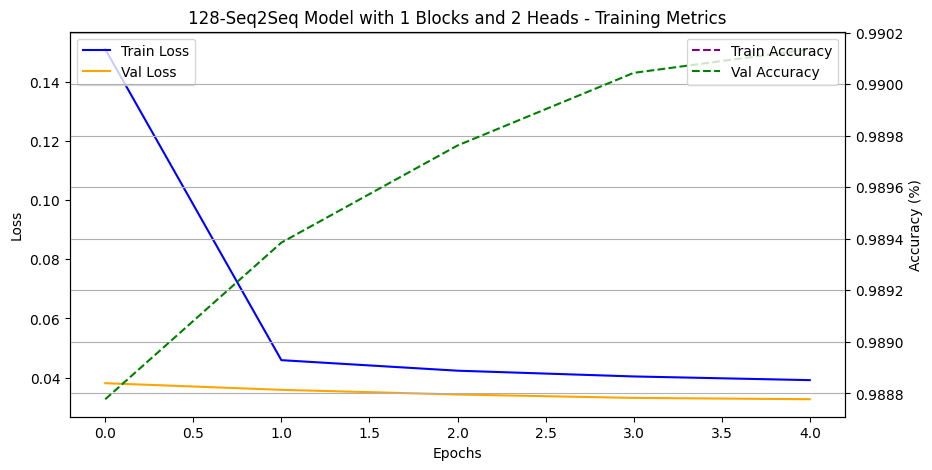



Training Config: Blocks=1, Heads=4

--- Training Char Transformer for Seq Length: 50 ---
609729
Time: 24.79s | Train Loss: 0.1449 | Val Loss: 0.0368 Val Accuracy: 0.9892
Time: 25.01s | Train Loss: 0.0373 | Val Loss: 0.0332 Val Accuracy: 0.9900
Time: 25.22s | Train Loss: 0.0351 | Val Loss: 0.0322 Val Accuracy: 0.9903
Time: 25.24s | Train Loss: 0.0340 | Val Loss: 0.0315 Val Accuracy: 0.9904
Time: 25.18s | Train Loss: 0.0333 | Val Loss: 0.0309 Val Accuracy: 0.9905
Average time per epoch: 25.09 seconds
  Execution Time: 125.45s | PPL: 1.03
  Generated Text Sample:
  " First Citizen: Before we proceed any further, hear the state, The shall the state the state the state, The sha "


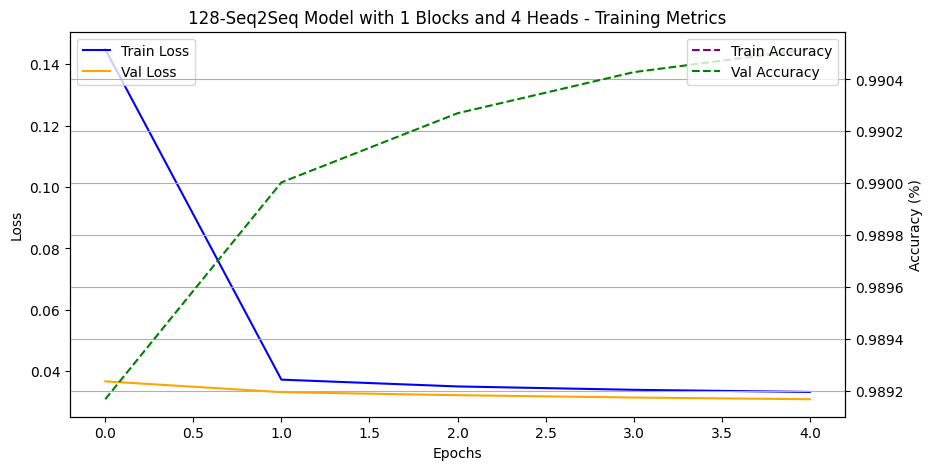



Training Config: Blocks=2, Heads=2

--- Training Char Transformer for Seq Length: 50 ---
1202753
Time: 40.11s | Train Loss: 0.1287 | Val Loss: 0.0360 Val Accuracy: 0.9893
Time: 40.24s | Train Loss: 0.0373 | Val Loss: 0.0333 Val Accuracy: 0.9900
Time: 40.10s | Train Loss: 0.0348 | Val Loss: 0.0319 Val Accuracy: 0.9904
Time: 40.03s | Train Loss: 0.0335 | Val Loss: 0.0308 Val Accuracy: 0.9906
Time: 40.38s | Train Loss: 0.0327 | Val Loss: 0.0302 Val Accuracy: 0.9908
Average time per epoch: 40.17 seconds
  Execution Time: 200.86s | PPL: 1.03
  Generated Text Sample:
  " First Citizen: Before we proceed any further, hear the come the come the come the come the come the come the c "


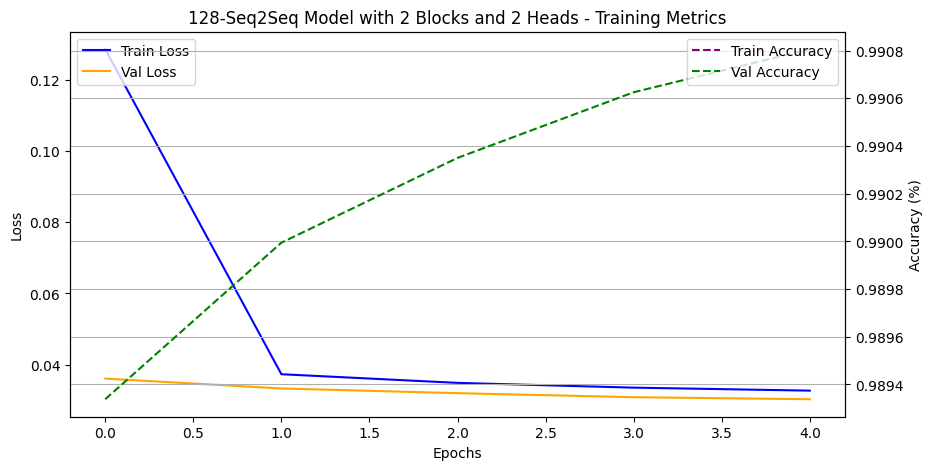



Training Config: Blocks=2, Heads=4

--- Training Char Transformer for Seq Length: 50 ---
1202753
Time: 40.12s | Train Loss: 0.1307 | Val Loss: 0.0349 Val Accuracy: 0.9895
Time: 40.66s | Train Loss: 0.0355 | Val Loss: 0.0323 Val Accuracy: 0.9902
Time: 40.67s | Train Loss: 0.0335 | Val Loss: 0.0312 Val Accuracy: 0.9905
Time: 40.63s | Train Loss: 0.0324 | Val Loss: 0.0305 Val Accuracy: 0.9907
Time: 40.51s | Train Loss: 0.0316 | Val Loss: 0.0298 Val Accuracy: 0.9909
Average time per epoch: 40.52 seconds
  Execution Time: 202.59s | PPL: 1.03
  Generated Text Sample:
  " First Citizen: Before we proceed any further, hear the prove The proud the proud the prove the proud the proud "


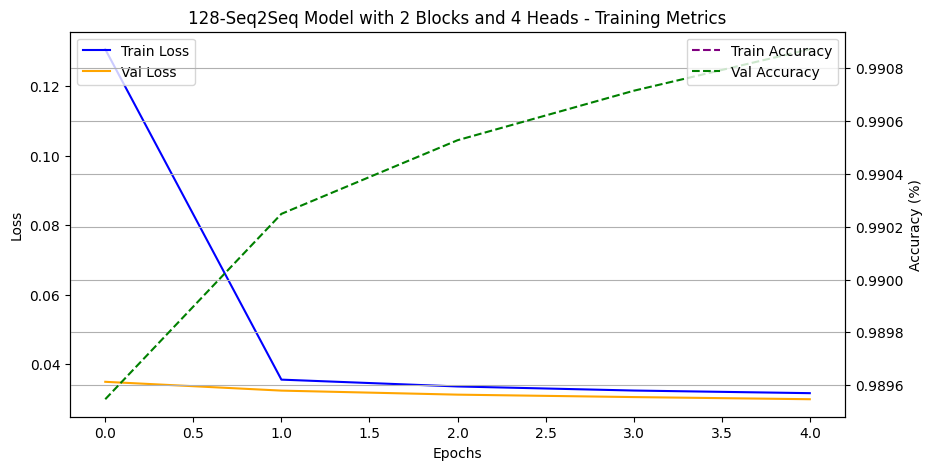



Training Config: Blocks=4, Heads=2

--- Training Char Transformer for Seq Length: 50 ---
2388801
Time: 70.22s | Train Loss: 0.1382 | Val Loss: 0.0346 Val Accuracy: 0.9897
Time: 70.38s | Train Loss: 0.0356 | Val Loss: 0.0320 Val Accuracy: 0.9903
Time: 70.58s | Train Loss: 0.0338 | Val Loss: 0.0310 Val Accuracy: 0.9905
Time: 70.79s | Train Loss: 0.0328 | Val Loss: 0.0302 Val Accuracy: 0.9907
Time: 70.80s | Train Loss: 0.0320 | Val Loss: 0.0297 Val Accuracy: 0.9909
Average time per epoch: 70.55 seconds
  Execution Time: 352.77s | PPL: 1.03
  Generated Text Sample:
  " First Citizen: Before we proceed any further, hear the father That the come the come the come the come the com "


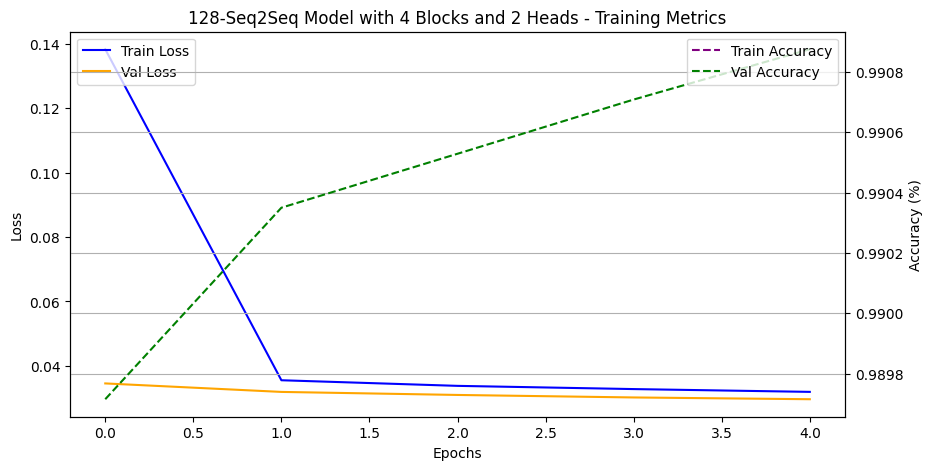



Training Config: Blocks=4, Heads=4

--- Training Char Transformer for Seq Length: 50 ---
2388801
Time: 71.53s | Train Loss: 0.1314 | Val Loss: 0.0345 Val Accuracy: 0.9897
Time: 71.72s | Train Loss: 0.0350 | Val Loss: 0.0319 Val Accuracy: 0.9903
Time: 71.52s | Train Loss: 0.0331 | Val Loss: 0.0312 Val Accuracy: 0.9906
Time: 71.83s | Train Loss: 0.0321 | Val Loss: 0.0299 Val Accuracy: 0.9908
Time: 71.85s | Train Loss: 0.0314 | Val Loss: 0.0294 Val Accuracy: 0.9910
Average time per epoch: 71.69 seconds
  Execution Time: 358.46s | PPL: 1.03
  Generated Text Sample:
  " First Citizen: Before we proceed any further, hear the son, That the stand the stand the stand the stand.  KIN "


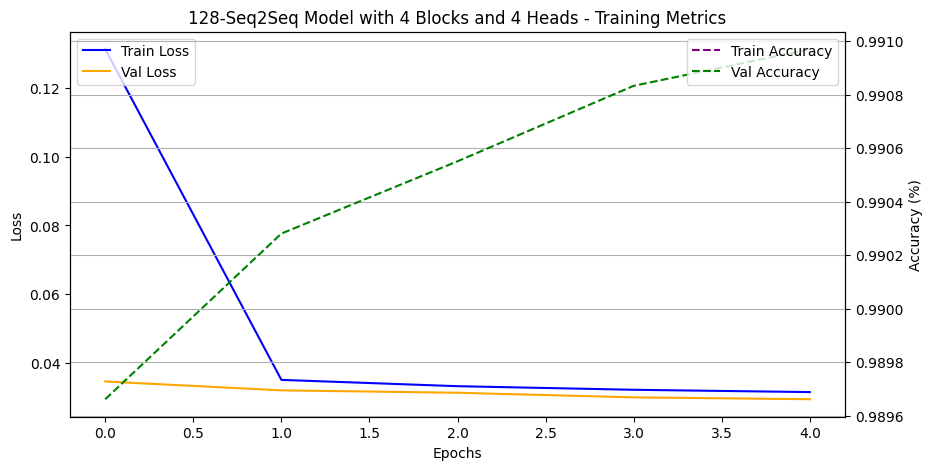



Training Config: Blocks=2, Heads=2

--- Training Char Transformer for Seq Length: 50 ---
2663489
Time: 69.01s | Train Loss: 0.0989 | Val Loss: 0.0357 Val Accuracy: 0.9894
Time: 69.01s | Train Loss: 0.0371 | Val Loss: 0.0333 Val Accuracy: 0.9900
Time: 69.05s | Train Loss: 0.0350 | Val Loss: 0.0321 Val Accuracy: 0.9903
Time: 69.34s | Train Loss: 0.0336 | Val Loss: 0.0310 Val Accuracy: 0.9905
Time: 69.36s | Train Loss: 0.0326 | Val Loss: 0.0301 Val Accuracy: 0.9908
Average time per epoch: 69.15 seconds
  Execution Time: 345.77s | PPL: 1.03
  Generated Text Sample:
  " First Citizen: Before we proceed any further, heart the shall be the comes the comes the comes the comes the c "


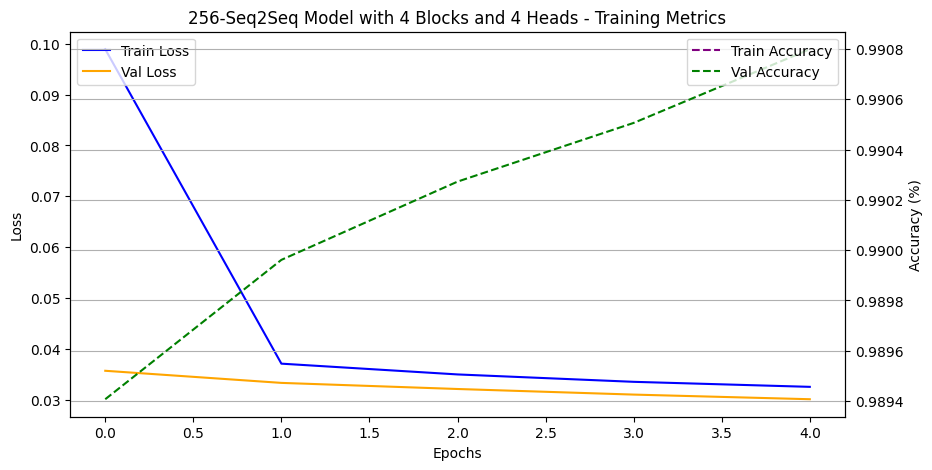

In [13]:
#seq 30
blocks = [1, 2, 4]
heads = [2, 4]

for b in blocks:
    for h in heads:
        print(f"Training Config: Blocks={b}, Heads={h}")
        train_shakesperetransformer(seq_length=50, epochs=5, learning_rate=0.001, d_model=128, num_heads=h, num_layers=b, batch_size=256, title=f"128-Seq2Seq Model with {b} Blocks and {h} Heads")
        print("\n")
print(f"Training Config: Blocks=2, Heads=2")
train_shakesperetransformer(seq_length=50, epochs=5, learning_rate=0.001, d_model=256, num_heads=2, num_layers=2, batch_size=256, title=f"256-Seq2Seq Model with {b} Blocks and {h} Heads")
print("\n")

In [14]:
filepath = '/content/drive/MyDrive/Intro_to_Deep_Learning/vast_english_french.txt'

In [15]:
SOS_token = 0
EOS_token = 1
PAD_token = 2

#Eng and Free will both have a class
class Lang:
  def __init__(self, name):
    self.name = name
    self.word2index = {}
    self.word2count = {}
    self.index2word = {0: "SOS", 1: "EOS", 2: "PAD"}
    self.n_words = 3

  # When adding a sentence we want to add each word in the sentence to our
  # language dictionary
  def addSentence(self, sentence):
    for word in sentence.split(' '):
      self.addWord(word)
  #If the word isn't in the dictionary, add it with a new index and then add it to the index2word as well
  def addWord(self, word):
    if word not in self.word2index:
      self.word2index[word] = self.n_words
      self.word2count[word] = 1
      self.index2word[self.n_words] = word
      self.n_words += 1
    else:
      self.word2count

# Lowercase, trim, and remove non-letter characters
def normalizeString(s):
    s = s.lower().strip()
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

def readLangs(lang1, lang2, filepath, reverse=False):
    # Read the file and split into lines
    lines = open(filepath , encoding='utf-8').\
        read().strip().split('\n')

    # Split every line into pairs and normalize
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]

    # Reverse pairs, make Lang instances
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

In [16]:

class Seq2SeqTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers):
        super(Seq2SeqTransformer, self).__init__()
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD_token)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD_token)
        self.pos_encoder = PositionalEncoding(d_model)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=num_heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            batch_first=True
        )
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask, memory_key_padding_mask):
        src_emb = self.pos_encoder(self.src_embedding(src))
        tgt_emb = self.pos_encoder(self.tgt_embedding(tgt))

        outs = self.transformer(
            src_emb, tgt_emb,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            memory_mask=None,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )
        return self.fc_out(outs)

def generate_square_subsequent_mask( sz):
      mask = (torch.triu(torch.ones(sz, sz, device=device)) == 1).transpose(0, 1)
      mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
      return mask
def create_mask(self, src, tgt, pad_idx):
      src_seq_len = src.shape[1]
      tgt_seq_len = tgt.shape[1]

      tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
      src_mask = torch.zeros((src_seq_len, src_seq_len), device=device).type(torch.bool)

      # Padding masks: True where the token is padding
      src_padding_mask = (src == pad_idx)
      tgt_padding_mask = (tgt == pad_idx)

      return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

In [17]:
MAX_LENGTH = 15
def filterPair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and \
        len(p[1].split(' ')) < MAX_LENGTH


def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

In [18]:
def prepareData(lang1, lang2, filepath, reverse=False):
    print("Reading lines...")
    input_lang, output_lang, pairs = readLangs(lang1, lang2,filepath, reverse)
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

# Initialize global input_lang and output_lang for random choice and other evaluation if needed
global input_lang, output_lang, pairs
input_lang, output_lang, pairs = prepareData('eng', 'fra', filepath, False)
print(random.choice(pairs))

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
eng 1003
fra 1127
['we swim during summer', 'nous nageons pendant l t']


In [19]:
def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]

def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1)

def tensorsFromPair(input_lang, output_lang, pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

def pairs_to_dataloader(dataset_pairs, sampler_class, batch_size, input_lang, output_lang, drop_last=False):
    n = len(dataset_pairs)
    input_ids = np.full((n, MAX_LENGTH), PAD_token, dtype=np.int32)
    target_ids = np.full((n, MAX_LENGTH), PAD_token, dtype=np.int32)

    for idx, (inp, tgt) in enumerate(dataset_pairs):
        inp_ids = indexesFromSentence(input_lang, inp)
        tgt_ids = indexesFromSentence(output_lang, tgt)
        inp_ids.append(EOS_token)
        tgt_ids.append(EOS_token)
        input_ids[idx, :len(inp_ids)] = inp_ids
        target_ids[idx, :len(tgt_ids)] = tgt_ids

    data = TensorDataset(torch.LongTensor(input_ids).to(device),
                                torch.LongTensor(target_ids).to(device))

    sampler = sampler_class(data)
    dataloader = DataLoader(data, sampler=sampler, batch_size=batch_size, drop_last=drop_last)
    return dataloader

def get_dataloaders(batch_size, reverse=False):
    filepath = '/content/drive/MyDrive/Intro_to_Deep_Learning/vast_english_french.txt'
    input_lang, output_lang, pairs = prepareData('eng', 'fra', filepath, reverse)

    # Split pairs into train and validation sets with a fixed random_state
    train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

    # Pass the locally defined input_lang and output_lang to pairs_to_dataloader
    train_dataloader = pairs_to_dataloader(train_pairs, RandomSampler, batch_size, input_lang, output_lang)
    from torch.utils.data import SequentialSampler
    val_dataloader = pairs_to_dataloader(val_pairs, SequentialSampler, batch_size, input_lang, output_lang)

    return input_lang, output_lang, train_dataloader, val_dataloader, val_pairs

In [20]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token) # Do NOT penalize predictions on padding

def train_epoch(model, optimizer, train_loader):
    model.train()
    total_loss = 0

    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)

        # Shift the target: input to decoder is tgt[:-1], label is tgt[1:]
        tgt_input = tgt[:, :-1]
        tgt_out = tgt[:, 1:]

        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input, PAD_IDX)

        logits = model(
            src, tgt_input,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            src_padding_mask=src_padding_mask,
            tgt_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask
        )

        optimizer.zero_grad()
        # Flatten the outputs and targets for CrossEntropyLoss
        loss = criterion(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

def greedy_decode(model, src, max_len, start_symbol):
    model.eval()
    src = src.to(device)
    src_mask = torch.zeros((src.shape[1], src.shape[1]), device=device).type(torch.bool)

    with torch.no_grad():
        # Encode source sequence once
        src_emb = model.positional_encoding(model.src_tok_emb(src).transpose(0, 1)).transpose(0, 1)
        memory = model.transformer.encoder(src_emb, src_mask)

        # Start with the SOS token
        tgt = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(device)

        for i in range(max_len - 1):
            tgt_mask = generate_square_subsequent_mask(tgt.size(1)).to(device)
            tgt_emb = model.positional_encoding(model.tgt_tok_emb(tgt).transpose(0, 1)).transpose(0, 1)

            # Decode step
            out = model.transformer.decoder(tgt_emb, memory, tgt_mask)
            prob = model.generator(out[:, -1]) # Look only at the last predicted word

            _, next_word = torch.max(prob, dim=1)
            next_word = next_word.item()

            tgt = torch.cat([tgt, torch.ones(1, 1).type_as(src.data).fill_(next_word)], dim=1)
            if next_word == EOS_token:
                break

    return tgt.flatten()

def evaluate_translation(model, src_sentence_tensor, tgt_vocab_list):
    # Pass tensor through greedy decode
    pred_tokens = greedy_decode(model, src_sentence_tensor.unsqueeze(0), max_len=50, start_symbol=SOS_token)

    # Convert token IDs back to strings using your vocabulary dictionary
    pred_words = [tgt_vocab_list[tok.item()] for tok in pred_tokens if tok.item() not in [SOS_token, EOS_token, PAD_token]]
    return pred_words

# Example BLEU Calculation for your report:
# smoothie = SmoothingFunction().method4
# score = sentence_bleu([reference_words_list], pred_words_list, smoothing_function=smoothie)

In [21]:
def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

In [22]:
from torch.optim import lr_scheduler # Added for learning rate scheduler

# Global constants (assuming these are defined in other cells and are needed here)
SOS_token = 0
EOS_token = 1
PAD_token = 2
PAD_IDX = PAD_token # Alias for consistency
MAX_LENGTH = 15 # Max sequence length for translation (from U90D8DpLQTTj)

# Criterion for Seq2SeqTransformer (from L81_LlVJwi40)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token) # Do NOT penalize predictions on padding

# Helper functions for Seq2SeqTransformer (adapted from Viei4A5-4X0G and L81_LlVJwi40)
def generate_square_subsequent_mask(sz):
    mask = (torch.triu(torch.ones(sz, sz, device=device)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask

def create_mask(src, tgt, pad_idx):
    src_seq_len = src.shape[1]
    tgt_seq_len = tgt.shape[1]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=device).type(torch.bool)

    # Padding masks: True where the token is padding
    src_padding_mask = (src == pad_idx)
    tgt_padding_mask = (tgt == pad_idx)

    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

def train_epoch(model, optimizer, train_loader):
    model.train()
    total_loss = 0

    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)

        # Shift the target: input to decoder is tgt[:-1], label is tgt[1:]
        tgt_input = tgt[:, :-1]
        tgt_out = tgt[:, 1:]

        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input, PAD_token)

        logits = model(
            src, tgt_input,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            src_padding_mask=src_padding_mask,
            tgt_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask
        )

        optimizer.zero_grad()
        # Flatten the outputs and targets for CrossEntropyLoss
        loss = criterion(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

def val_epoch(model, val_loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1]
            tgt_out = tgt[:, 1:]

            src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input, PAD_token)

            logits = model(
                src, tgt_input,
                src_mask=src_mask,
                tgt_mask=tgt_mask,
                src_padding_mask=src_padding_mask,
                tgt_padding_mask=tgt_padding_mask,
                memory_key_padding_mask=src_padding_mask
            )
            loss = criterion(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
            total_loss += loss.item()
    return total_loss / len(val_loader)

def greedy_decode(model, src, max_len, start_symbol):
    model.eval()
    src = src.to(device)
    # Dummy tgt for create_mask, actual tgt will be built iteratively
    dummy_tgt_for_mask = torch.zeros(src.shape[0], 1, dtype=torch.long, device=device)

    with torch.no_grad():
        # Get src_mask and src_padding_mask once for the encoder input
        src_mask_encoder, _, src_padding_mask_encoder, _ = create_mask(src, dummy_tgt_for_mask, PAD_token)

        # Encode source sequence once
        src_emb = model.pos_encoder(model.src_embedding(src))
        memory = model.transformer.encoder(src_emb, src_mask_encoder, src_padding_mask_encoder)

        # Start with the SOS token
        tgt_tokens = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(device)

        for i in range(max_len - 1):
            # For each decoding step, generate new masks for the growing target sequence
            _, tgt_mask_decoder, _, tgt_padding_mask_decoder = create_mask(src, tgt_tokens, PAD_token)

            tgt_emb = model.pos_encoder(model.tgt_embedding(tgt_tokens))

            # Decode step
            out = model.transformer.decoder(
                tgt_emb,
                memory,
                tgt_mask=tgt_mask_decoder,
                tgt_key_padding_mask=tgt_padding_mask_decoder,
                memory_key_padding_mask=src_padding_mask_encoder # Decoder cross-attention to encoder output padding
            )
            prob = model.fc_out(out[:, -1, :]) # Logits for the last token in the target sequence
            _, next_word = torch.max(prob, dim=1)
            next_word = next_word.item()

            tgt_tokens = torch.cat([tgt_tokens, torch.ones(1, 1).type_as(src.data).fill_(next_word)], dim=1)
            if next_word == EOS_token:
                break

    return tgt_tokens.flatten()

def train(model, train_dataloader, val_dataloader, n_epochs, learning_rate=0.001,
               print_every=100):
    start = time.time()
    train_loss_history = []
    val_loss_history = []
    print_loss_total = 0  # Reset every print_every
    print_val_loss_total = 0 # Added for validation loss

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

    # Initialize learning rate scheduler
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    best_val_loss = float('inf')
    best_epoch = 0
    best_model_state = None

    for epoch in range(1, n_epochs + 1):
        # Training
        train_loss = train_epoch(model, optimizer, train_dataloader)
        print_loss_total += train_loss
        train_loss_history.append(train_loss)

        # Validation
        val_loss = val_epoch(model, val_dataloader)
        print_val_loss_total += val_loss
        val_loss_history.append(val_loss)

        # Step the LR scheduler based on validation loss
        scheduler.step(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model_state = model.state_dict() # Save best model state

        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_val_loss_avg = print_val_loss_total / print_every
            print_loss_total = 0
            print_val_loss_total = 0

            print(f'{timeSince(start, epoch / n_epochs)} Epoch: {epoch} Percentage Complete:{epoch / n_epochs * 100:.0f}% Train Loss: {print_loss_avg:.4f} Val Loss: {print_val_loss_avg:.4f}')

    # Load the best model states after training
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nBest model loaded from epoch {best_epoch} with validation loss: {best_val_loss:.4f}")

    return train_loss_history, val_loss_history, best_epoch

def evaluate(model, sentence, input_lang, output_lang):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)

        pred_tokens = greedy_decode(model, input_tensor, max_len=MAX_LENGTH, start_symbol=SOS_token)

        decoded_words = []
        for idx in pred_tokens:
            if idx.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            decoded_words.append(output_lang.index2word[idx.item()])
    return decoded_words

def evaluate_dataset(model, pairs, input_lang, output_lang, num_examples=5):
    model.eval()

    exact_matches = 0
    bleu_scores = []
    inference_time = []
    smoothie = SmoothingFunction().method4

    print(f"Evaluating on {len(pairs)} validation pairs...")

    for i, pair in enumerate(pairs):
        input_sentence = pair[0]
        target_sentence = pair[1]
        inference_start_time = time.time()
        output_words_with_eos = evaluate(model, input_sentence, input_lang, output_lang)
        inference_duration = time.time() - inference_start_time
        inference_time.append(inference_duration)
        output_words = [w for w in output_words_with_eos if w not in ['<EOS>', 'SOS']] # Remove the <EOS> token for BLEU and display
        output_sentence = ' '.join(output_words)

        if output_sentence.strip() == target_sentence.strip():
            exact_matches += 1

        reference = [target_sentence.split()]
        candidate = output_sentence.split()
        bleu = sentence_bleu(reference, candidate, smoothing_function=smoothie)
        bleu_scores.append(bleu)

        if i < num_examples: # Display basic info for num_examples
            print('>', input_sentence)
            print('=', target_sentence)
            print('<', output_sentence)
            print(f'BLEU: {bleu:.4f}')

    accuracy = exact_matches / len(pairs)
    avg_bleu = sum(bleu_scores) / len(bleu_scores)
    avg_inference_time = sum(inference_time) / len(inference_time)

    print(f"Validation Accuracy (Exact Match): {accuracy:.4f}")
    print(f"Validation Average BLEU Score: {avg_bleu:.4f}")
    print(f"Validation Average Inference Time: {avg_inference_time:.4f}s")

In [111]:
input_lang, output_lang, train_dataloader, val_dataloader, val_pairs = get_dataloaders(batch_size=32)
# Use this loop structure for evaluating the 8 combinations required for P2, P3, and P4.
blocks = [1, 2, 4]
heads = [2, 4]

for b in blocks:
    for h in heads:
        print(f"Training Config: Blocks={b}, Heads={h}")

        # Instantiate the Seq2SeqTransformer model
        d_model = 128

        model = Seq2SeqTransformer(
            src_vocab_size=input_lang.n_words,
            tgt_vocab_size=output_lang.n_words,
            d_model=d_model,
            num_heads=h,
            num_layers=b
        ).to(device)

        print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

        n_epochs = 50
        learning_rate = 0.001
        print_every = 1

        print("Starting Seq2SeqTransformer training...")

        train_loss_history, val_loss_history, best_epoch = train(
            model=model,
            train_dataloader=train_dataloader,
            val_dataloader=val_dataloader,
            n_epochs=n_epochs,
            learning_rate=learning_rate,
            print_every=print_every
        )

        print("\nTraining complete. Evaluating on validation dataset...")

        evaluate_dataset(model, val_pairs, input_lang, output_lang, num_examples=5)

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
eng 1003
fra 1127
Training Config: Blocks=1, Heads=2
Model parameters: 1670887
Starting Seq2SeqTransformer training...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


0m 0s (- 0m 7s) Epoch: 1 Percentage Complete:2% Train Loss: 6.3360 Val Loss: 5.9395
0m 0s (- 0m 7s) Epoch: 2 Percentage Complete:4% Train Loss: 5.6420 Val Loss: 5.6794
0m 0s (- 0m 7s) Epoch: 3 Percentage Complete:6% Train Loss: 5.1584 Val Loss: 5.4378
0m 0s (- 0m 7s) Epoch: 4 Percentage Complete:8% Train Loss: 4.6553 Val Loss: 5.1848
0m 0s (- 0m 7s) Epoch: 5 Percentage Complete:10% Train Loss: 4.1417 Val Loss: 4.9624
0m 0s (- 0m 6s) Epoch: 6 Percentage Complete:12% Train Loss: 3.6751 Val Loss: 4.8365
0m 1s (- 0m 6s) Epoch: 7 Percentage Complete:14% Train Loss: 3.2385 Val Loss: 4.7341
0m 1s (- 0m 6s) Epoch: 8 Percentage Complete:16% Train Loss: 2.8309 Val Loss: 4.6145
0m 1s (- 0m 6s) Epoch: 9 Percentage Complete:18% Train Loss: 2.4584 Val Loss: 4.5396
0m 1s (- 0m 6s) Epoch: 10 Percentage Complete:20% Train Loss: 2.1095 Val Loss: 4.4305
0m 1s (- 0m 6s) Epoch: 11 Percentage Complete:22% Train Loss: 1.7826 Val Loss: 4.4210
0m 1s (- 0m 5s) Epoch: 12 Percentage Complete:24% Train Loss: 1.490

In [23]:
input_lang, output_lang, train_dataloader, val_dataloader, val_pairs = get_dataloaders(batch_size=32)
# Use this loop structure for evaluating the 8 combinations required for P2, P3, and P4.
blocks = [4]
heads = [2, 4]

for b in blocks:
    for h in heads:
        print(f"Training Config: Blocks={b}, Heads={h}")

        # Instantiate the Seq2SeqTransformer model
        d_model = 128

        model = Seq2SeqTransformer(
            src_vocab_size=input_lang.n_words,
            tgt_vocab_size=output_lang.n_words,
            d_model=d_model,
            num_heads=h,
            num_layers=b
        ).to(device)

        print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

        n_epochs = 150
        learning_rate = 0.001
        print_every = 1

        print("Starting Seq2SeqTransformer training...")

        train_loss_history, val_loss_history, best_epoch = train(
            model=model,
            train_dataloader=train_dataloader,
            val_dataloader=val_dataloader,
            n_epochs=n_epochs,
            learning_rate=learning_rate,
            print_every=print_every
        )

        print("\nTraining complete. Evaluating on validation dataset...")

        evaluate_dataset(model, val_pairs, input_lang, output_lang, num_examples=5)

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
eng 1003
fra 1127
Training Config: Blocks=4, Heads=2
Model parameters: 5427943
Starting Seq2SeqTransformer training...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


0m 0s (- 1m 49s) Epoch: 1 Percentage Complete:1% Train Loss: 6.3126 Val Loss: 5.9700
0m 1s (- 1m 28s) Epoch: 2 Percentage Complete:1% Train Loss: 5.7986 Val Loss: 5.9844
0m 1s (- 1m 20s) Epoch: 3 Percentage Complete:2% Train Loss: 5.7254 Val Loss: 6.0852
0m 2s (- 1m 16s) Epoch: 4 Percentage Complete:3% Train Loss: 5.7125 Val Loss: 6.1418
0m 2s (- 1m 13s) Epoch: 5 Percentage Complete:3% Train Loss: 5.6983 Val Loss: 6.1788
0m 2s (- 1m 11s) Epoch: 6 Percentage Complete:4% Train Loss: 5.6820 Val Loss: 6.1990
0m 3s (- 1m 10s) Epoch: 7 Percentage Complete:5% Train Loss: 5.6875 Val Loss: 6.2093
0m 3s (- 1m 9s) Epoch: 8 Percentage Complete:5% Train Loss: 5.6824 Val Loss: 6.2275
0m 4s (- 1m 7s) Epoch: 9 Percentage Complete:6% Train Loss: 5.6740 Val Loss: 6.2413
0m 4s (- 1m 6s) Epoch: 10 Percentage Complete:7% Train Loss: 5.6669 Val Loss: 6.2497
0m 5s (- 1m 6s) Epoch: 11 Percentage Complete:7% Train Loss: 5.6697 Val Loss: 6.2511
0m 5s (- 1m 5s) Epoch: 12 Percentage Complete:8% Train Loss: 5.6485

In [112]:
input_lang, output_lang, train_dataloader, val_dataloader, val_pairs = get_dataloaders(batch_size=32, reverse=True)
# Use this loop structure for evaluating the 8 combinations required for P2, P3, and P4.
blocks = [1, 2, 4]
heads = [2, 4]

for b in blocks:
    for h in heads:
        print(f"Training Config: Blocks={b}, Heads={h}")

        # Instantiate the Seq2SeqTransformer model
        d_model = 128

        model = Seq2SeqTransformer(
            src_vocab_size=input_lang.n_words,
            tgt_vocab_size=output_lang.n_words,
            d_model=d_model,
            num_heads=h,
            num_layers=b
        ).to(device)

        print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

        n_epochs = 50
        learning_rate = 0.001
        print_every = 1

        print("Starting Seq2SeqTransformer training...")

        train_loss_history, val_loss_history, best_epoch = train(
            model=model,
            train_dataloader=train_dataloader,
            val_dataloader=val_dataloader,
            n_epochs=n_epochs,
            learning_rate=learning_rate,
            print_every=print_every
        )

        print("\nTraining complete. Evaluating on validation dataset...")

        evaluate_dataset(model, val_pairs, input_lang, output_lang, num_examples=5)

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
fra 1127
eng 1003
Training Config: Blocks=1, Heads=2
Model parameters: 1654891
Starting Seq2SeqTransformer training...
0m 0s (- 0m 7s) Epoch: 1 Percentage Complete:2% Train Loss: 6.0895 Val Loss: 5.7354
0m 0s (- 0m 7s) Epoch: 2 Percentage Complete:4% Train Loss: 5.4318 Val Loss: 5.5519
0m 0s (- 0m 7s) Epoch: 3 Percentage Complete:6% Train Loss: 4.9664 Val Loss: 5.3260
0m 0s (- 0m 7s) Epoch: 4 Percentage Complete:8% Train Loss: 4.4633 Val Loss: 5.1331
0m 0s (- 0m 7s) Epoch: 5 Percentage Complete:10% Train Loss: 3.9847 Val Loss: 4.9820
0m 0s (- 0m 6s) Epoch: 6 Percentage Complete:12% Train Loss: 3.5474 Val Loss: 4.8453
0m 1s (- 0m 6s) Epoch: 7 Percentage Complete:14% Train Loss: 3.1196 Val Loss: 4.7870
0m 1s (- 0m 6s) Epoch: 8 Percentage Complete:16% Train Loss: 2.7315 Val Loss: 4.6830
0m 1s (- 0m 6s) Epoch: 9 Percentage Complete:18% Train Loss: 2.3710 Val Loss: 4.6225
0m 1s (- 0m 6s) 

In [24]:
input_lang, output_lang, train_dataloader, val_dataloader, val_pairs = get_dataloaders(batch_size=32, reverse=True)
# Use this loop structure for evaluating the 8 combinations required for P2, P3, and P4.
blocks = [4]
heads = [2, 4]

for b in blocks:
    for h in heads:
        print(f"Training Config: Blocks={b}, Heads={h}")

        # Instantiate the Seq2SeqTransformer model
        d_model = 128

        model = Seq2SeqTransformer(
            src_vocab_size=input_lang.n_words,
            tgt_vocab_size=output_lang.n_words,
            d_model=d_model,
            num_heads=h,
            num_layers=b
        ).to(device)

        print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

        n_epochs = 150
        learning_rate = 0.001
        print_every = 1

        print("Starting Seq2SeqTransformer training...")

        train_loss_history, val_loss_history, best_epoch = train(
            model=model,
            train_dataloader=train_dataloader,
            val_dataloader=val_dataloader,
            n_epochs=n_epochs,
            learning_rate=learning_rate,
            print_every=print_every
        )

        print("\nTraining complete. Evaluating on validation dataset...")

        evaluate_dataset(model, val_pairs, input_lang, output_lang, num_examples=5)

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
fra 1127
eng 1003
Training Config: Blocks=4, Heads=2
Model parameters: 5411947
Starting Seq2SeqTransformer training...
0m 0s (- 1m 9s) Epoch: 1 Percentage Complete:1% Train Loss: 6.0959 Val Loss: 5.8202
0m 0s (- 1m 7s) Epoch: 2 Percentage Complete:1% Train Loss: 5.6401 Val Loss: 5.8577
0m 1s (- 1m 6s) Epoch: 3 Percentage Complete:2% Train Loss: 5.5620 Val Loss: 5.9508
0m 1s (- 1m 6s) Epoch: 4 Percentage Complete:3% Train Loss: 5.5506 Val Loss: 6.0182
0m 2s (- 1m 5s) Epoch: 5 Percentage Complete:3% Train Loss: 5.5432 Val Loss: 6.0403
0m 2s (- 1m 4s) Epoch: 6 Percentage Complete:4% Train Loss: 5.4768 Val Loss: 5.9454
0m 3s (- 1m 4s) Epoch: 7 Percentage Complete:5% Train Loss: 5.3852 Val Loss: 5.8776
0m 3s (- 1m 4s) Epoch: 8 Percentage Complete:5% Train Loss: 5.2722 Val Loss: 5.7789
0m 4s (- 1m 3s) Epoch: 9 Percentage Complete:6% Train Loss: 5.1014 Val Loss: 5.6668
0m 4s (- 1m 3s) Epoch